# Financial Sentiment Analysis: Domain Transfer Across Social Media Registers

This notebook investigates the transferability of financial sentiment models across linguistic domains, from curated financial Twitter data to the informal, meme-driven language of Reddit's WallStreetBets (WSB) community. The central question is whether models trained on structured financial social media text can generalize to the radically different register of retail investor discourse, and whether financial domain pretraining provides an advantage over general pretraining when adapting to social media financial text.

Questions

- How severe is the domain gap between formal financial Twitter and informal WSB discourse, and can it be quantified?
- Does fine-tuning on a small amount of in-domain WSB data recover performance lost to the domain gap?
- Does WSB adaptation hurt generalization to formal financial text (Financial PhraseBank)?
- Does financial domain pretraining (FinBERT) outperform general pretraining (DistilBERT) in zero-shot and fine-tuned settings on social media financial text?

Datasets

- Twitter Financial News Sentiment (zeroshot/twitter-financial-news-sentiment), 11,931 curated financial tweets labeled Bullish, Bearish or Neutral. Used as primary training data.
- WallStreetBets (zchengc/wsb), 1,602 Reddit posts from r/WallStreetBets labeled Bullish, Bearish or Neutral. Used as domain adaptation training data and cross-domain evaluation set.
- Financial PhraseBank (warwickai/financial_phrasebank_mirror), 4,846 formal financial analyst sentences labeled Positive, Negative or Neutral. Used exclusively as a held-out generalization test set.

Models

- DistilBERT (distilbert-base-uncased), a general purpose lightweight transformer used as the domain-agnostic baseline
- FinBERT (ProsusAI/finbert), a BERT model pretrained on financial corpora and fine-tuned on Financial PhraseBank, used as the finance-specialized baseline

Experimental Design
Five experiments are conducted in sequence, progressively building toward the core research question:

- Experiment 1: DistilBERT fine-tuned on Twitter, evaluated on Twitter and WSB (establishes domain gap baseline)
- Experiment 2: DistilBERT fine-tuned on Twitter + WSB, evaluated on Twitter and WSB (measures domain adaptation effect)
- Experiment 3: Both DistilBERT models evaluated on Financial PhraseBank (measures formality generalization)
- Experiment 4: FinBERT zero-shot evaluated on Twitter and WSB (establishes finance-pretrained baseline)
- Experiment 5: FinBERT fine-tuned on Twitter + WSB, evaluated on Twitter and WSB (answers the core pretraining vs fine-tuning question)

All training experiments use three random seeds (26, 42, 74) with results reported as mean ± standard deviation. Balanced class weights are applied during training to handle class imbalance. Macro F1 is used as the primary evaluation metric to ensure equal weight across all three sentiment classes regardless of class frequency.

## Setup

### Libraries

In [1]:
## Necessary Libraries
import os

## Hugging face dataset library
from datasets import load_dataset, Dataset, concatenate_datasets, ClassLabel

## Manipulating data
import numpy as np
import pandas as pd
from collections import Counter

## String manipulation
import re
import emoji

## nltk
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

## Tokenization
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, pipeline, set_seed, EarlyStoppingCallback, DataCollatorWithPadding

## sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

## Pytorch
import torch

## Experimentation
import mlflow

## Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

## file saving
import json

## Setting the plot style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 11

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/rishabh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Config

In [2]:
## Modeling
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 100  # covers 100% of both datasets with margin, max observed is 97 tokens

## Data path
TWITTER_PATH = "zeroshot/twitter-financial-news-sentiment"
WSB_PATH = "zchengc/wsb"
PHRASEBANK_PATH = "warwickai/financial_phrasebank_mirror"
FINBERT_NAME = "ProsusAI/finbert"

## Training parameters
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
CHECKPOINT_DIR = './Checkpoints'
RESULTS_DIR = './Report/results'
FIGURE_DIR = './Report/figures'
LOGGING_DIR = './logs'
SEEDS = [26, 42, 74]
NEUTRAL_CONFIDENCE_THRESHOLD = 0.6 # minimum confidence for bullish/bearish prediction on StockTwits 
EVAL_METRIC = "eval_f1_macro"  # for model selection and early stopping
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# class weights will be computed after EDA once label distributions are confirmed
# included here as a reminder that training uses weighted cross entropy
USE_CLASS_WEIGHTS = True

## Experimentation
mlflow.set_tracking_uri("") # to be filled
MLFLOW_EXPERIMENT_DISTILBERT = "distilbert-domain-transfer"
MLFLOW_EXPERIMENT_FINBERT = "finbert-domain-transfer"

## Label mapping
LABEL2ID = {"Bearish": 0, "Bullish": 1, "Neutral": 2}
ID2LABEL = {2: "Neutral", 1: "Bullish",0: "Bearish"}
WSB_LABEL_MAP = {0: 1, 1: 0, 2: 2}
PHRASEBANK_LABEL_MAP = {0: 0, 1: 2, 2: 1}
FINBERT_LABEL_REMAP = {0: 1, 1: 0, 2: 2} 

In [3]:
## Making all the necessary directories
for path in [CHECKPOINT_DIR, RESULTS_DIR, FIGURE_DIR, LOGGING_DIR]:
    os.makedirs(path, exist_ok=True)

## EDA

### Loading data and basic analysis
In this subsection the data is loaded and splits are checked and labels are remapped so that the two datasets are consistent.

__Twitter Financial News Sentiment__

The Twitter Financial News Sentiment dataset is sourced from HuggingFace (zeroshot/twitter-financial-news-sentiment) and contains financial tweets labeled across three sentiment classes: Bearish, Bullish, and Neutral. The dataset comes with a predefined train and validation split.

*Label mapping:* Raw labels are already aligned with our canonical mapping (Bearish=0, Bullish=1, Neutral=2) and require no remapping.

In [4]:
twitter_ds = load_dataset(TWITTER_PATH)

In [5]:
twitter_ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9543
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2388
    })
})

In [6]:
## size of train, validation set

print(f"Shape of the training dataset : {twitter_ds["train"].shape}")
print(f"Shape of the validation dataset : {twitter_ds["validation"].shape}")

Shape of the training dataset : (9543, 2)
Shape of the validation dataset : (2388, 2)


*Split strategy:* We treat the original validation set as our held-out test set, as it was carefully curated by the dataset authors. A new validation set is carved from the training data using a 90/10 stratified split, with stratification on the label column to preserve class proportions across all three splits. The data split uses a fixed seed of 26, independent of the training seeds, ensuring identical splits across all experiments.

In [7]:
## use 10% of training set as validation

twitter_data = twitter_ds["train"].cast_column("label", ClassLabel(names=["Bearish", "Bullish", "Neutral"]))
train_val = twitter_data.train_test_split(test_size=0.1, seed=26, stratify_by_column="label")
twitter_train = train_val["train"]
twitter_val = train_val["test"]
twitter_test = twitter_ds["validation"]  # original validation becomes our held-out test

In [8]:
## size of train, test, validation set

print(f"Shape of the train dataset : {twitter_train.shape}")
print(f"Shape of the validation dataset : {twitter_val.shape}")
print(f"Shape of the test dataset : {twitter_test.shape}")

Shape of the train dataset : (8588, 2)
Shape of the validation dataset : (955, 2)
Shape of the test dataset : (2388, 2)


In [9]:
## Converting to pandas for EDA only, tokenization and training use the original HuggingFace splits

twitter_train_df = twitter_train.to_pandas()
twitter_val_df = twitter_val.to_pandas()
twitter_test_df = twitter_test.to_pandas()

In [10]:
## Checking class imbalance across the three splits

print(f"Class distribution train set:\n{twitter_train_df["label"].map(ID2LABEL).value_counts(normalize = True)}")
print(f"Class distribution val set:\n{twitter_val_df["label"].map(ID2LABEL).value_counts(normalize = True)}")
print(f"Class distribution test set:\n{twitter_test_df["label"].map(ID2LABEL).value_counts(normalize = True)}")

Class distribution train set:
label
Neutral    0.647415
Bullish    0.201444
Bearish    0.151141
Name: proportion, dtype: float64
Class distribution val set:
label
Neutral    0.647120
Bullish    0.202094
Bearish    0.150785
Name: proportion, dtype: float64
Class distribution test set:
label
Neutral    0.655779
Bullish    0.198911
Bearish    0.145310
Name: proportion, dtype: float64


Stratification is consistent across all three splits. The dataset is heavily skewed toward Neutral (≈65%), with Bearish as the minority class (≈15%). This imbalance justifies the use of balanced class weights during training and macro F1 as the primary evaluation metric.


__WSB (WallStreetBets) Sentiment__

The WSB dataset is sourced from HuggingFace (zchengc/wsb) and contains Reddit posts from the r/WallStreetBets subreddit labeled across three sentiment classes: Bearish, Bullish, and Neutral. WallStreetBets is a highly informal financial community known for its distinctive slang, meme-driven discourse, and retail investor sentiment, representing a meaningfully different linguistic domain from curated financial Twitter data.

The dataset comes with predefined train, validation and test splits of 1200, 202 and 200 examples respectively. We use these splits as-is to respect the original data curation.

*Label remapping:* Raw WSB labels are remapped to the canonical mapping (Bearish=0, Bullish=1, Neutral=2) before any further processing.

*Dataset size:* With only 1,602 examples total, this dataset is significantly smaller than the Twitter data. WSB data is never used as a standalone training set, it is always combined with Twitter data to provide a domain adaptation signal.

In [11]:
wsb_ds = load_dataset(WSB_PATH)

In [12]:
wsb_ds

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'title', 'label'],
        num_rows: 1200
    })
    validation: Dataset({
        features: ['Unnamed: 0', 'title', 'label'],
        num_rows: 202
    })
    test: Dataset({
        features: ['Unnamed: 0', 'title', 'label'],
        num_rows: 200
    })
})

In [13]:
## Making the schema match the twitter news dataset

wsb_ds = wsb_ds.rename_column("title", "text")
wsb_ds = wsb_ds.remove_columns("Unnamed: 0")

In [14]:
## Label remapping

wsb_ds = wsb_ds.map(lambda x: {"label": WSB_LABEL_MAP[x["label"]]})

In [15]:
# Converting to pandas for EDA only, tokenization and training use the original HuggingFace splits

wsb_train_df = wsb_ds["train"].to_pandas()
wsb_val_df = wsb_ds["validation"].to_pandas()
wsb_test_df = wsb_ds["test"].to_pandas()

In [16]:
## Checking class imbalance across the three splits

print(f"Class distribution train set:\n{wsb_train_df["label"].map(ID2LABEL).value_counts(normalize = True)}")
print(f"Class distribution val set:\n{wsb_val_df["label"].map(ID2LABEL).value_counts(normalize = True)}")
print(f"Class distribution test set:\n{wsb_test_df["label"].map(ID2LABEL).value_counts(normalize = True)}")

Class distribution train set:
label
Neutral    0.4025
Bullish    0.3625
Bearish    0.2350
Name: proportion, dtype: float64
Class distribution val set:
label
Bullish    0.490099
Neutral    0.376238
Bearish    0.133663
Name: proportion, dtype: float64
Class distribution test set:
label
Neutral    0.450
Bearish    0.285
Bullish    0.265
Name: proportion, dtype: float64


Inspection of the predefined WSB splits reveals inconsistent class distributions across train, validation and test sets, the validation set contains 49% Bullish examples compared to 26% in the test set, indicating the original splits were not stratified. To ensure consistent and reliable evaluation, we discard the predefined splits and re-split the full dataset using stratified sampling.

The full 1,602 examples are pooled and re-split into train (68%), validation (12%) and test (20%) sets using a fixed seed of 26, with stratification on the label column to preserve class proportions across all splits. As with the Twitter data, the test set is defined here and not touched again until final evaluation.

In [17]:
## Combining the data
wsb_full_df = pd.concat([wsb_train_df, wsb_val_df, wsb_test_df], ignore_index=True)

## first split off test set (20%)
wsb_train_val_df, wsb_test_df = train_test_split(wsb_full_df, test_size=0.2, random_state=26, stratify=wsb_full_df["label"])

# then split remaining into train (85%) and val (15%)
wsb_train_df, wsb_val_df = train_test_split(wsb_train_val_df, test_size=0.15, random_state=26, stratify=wsb_train_val_df["label"])

In [18]:
print(f"WSB train: {wsb_train_df.shape}")
print(f"WSB val:   {wsb_val_df.shape}")
print(f"WSB test:  {wsb_test_df.shape}")

WSB train: (1088, 2)
WSB val:   (193, 2)
WSB test:  (321, 2)


In [19]:
## Checking class imbalance across the three splits

print(f"Class distribution train set:\n{wsb_train_df["label"].map(ID2LABEL).value_counts(normalize = True)}")
print(f"Class distribution val set:\n{wsb_val_df["label"].map(ID2LABEL).value_counts(normalize = True)}")
print(f"Class distribution test set:\n{wsb_test_df["label"].map(ID2LABEL).value_counts(normalize = True)}")

Class distribution train set:
label
Neutral    0.405331
Bullish    0.365809
Bearish    0.228860
Name: proportion, dtype: float64
Class distribution val set:
label
Neutral    0.404145
Bullish    0.367876
Bearish    0.227979
Name: proportion, dtype: float64
Class distribution test set:
label
Neutral    0.404984
Bullish    0.367601
Bearish    0.227414
Name: proportion, dtype: float64


Stratification is consistent across all three WSB splits. Unlike the Twitter data, WSB is considerably more balanced with Neutral at 40%, Bullish at 37% and Bearish at 23%. Bearish remains the minority class in both datasets, though less severely than in Twitter data. Class weights will be recomputed for the combined Twitter + WSB training set later.

### Detailed analysis and plots
In this subsection, full-fledged exploratory analysis is carried out

In [20]:
## Checking for null-value in twitter dataset

print(f"Null values twitter train set:\n{twitter_train_df.isna().mean()}")
print(f"Null values twitter val set:\n{twitter_val_df.isna().mean()}")
print(f"Null values twitter test set:\n{twitter_test_df.isna().mean()}")

Null values twitter train set:
text     0.0
label    0.0
dtype: float64
Null values twitter val set:
text     0.0
label    0.0
dtype: float64
Null values twitter test set:
text     0.0
label    0.0
dtype: float64


In [21]:
## Checking for null-value in WSB dataset

print(f"Null values WSB train set:\n{wsb_train_df.isna().mean()}")
print(f"Null values WSB val set:\n{wsb_val_df.isna().mean()}")
print(f"Null values WSB test set:\n{wsb_test_df.isna().mean()}")

Null values WSB train set:
text     0.0
label    0.0
dtype: float64
Null values WSB val set:
text     0.0
label    0.0
dtype: float64
Null values WSB test set:
text     0.0
label    0.0
dtype: float64


There are no missing values in the twitter or the WSB dataset, this makes our task slightly easier.

All further exploratory analysis is conducted on the training sets only. Validation and test sets are checked for null values as a sanity measure but are otherwise excluded from EDA to prevent any form of data leakage into modeling decisions.

#### Class Distribution

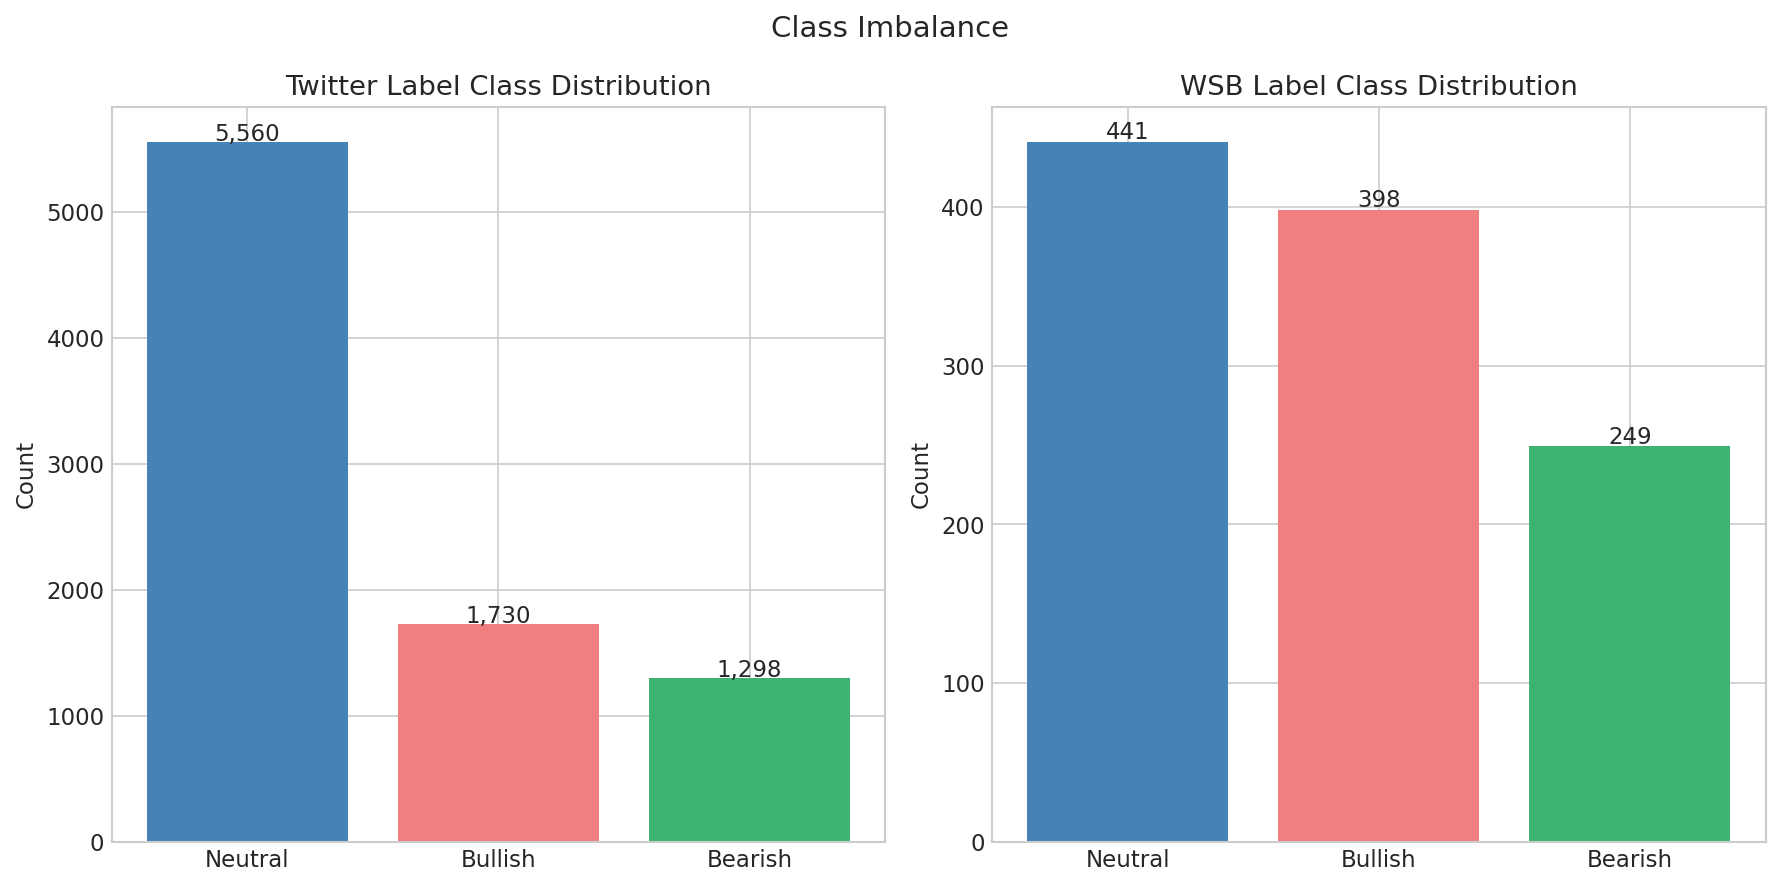

In [108]:
## Class imbalance plot

twitter_label_counts = twitter_train_df["label"].value_counts()
wsb_label_counts = wsb_train_df["label"].value_counts()
labels = [ID2LABEL[2], ID2LABEL[1], ID2LABEL[0]]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Bar chart twitter
axes[0].bar(labels, twitter_label_counts.values, color=["steelblue", "lightcoral", "Mediumseagreen"])
axes[0].set_title("Twitter Label Class Distribution")
axes[0].set_ylabel("Count")
axes[0].set_xticks([0,1,2])
for i, v in enumerate(twitter_label_counts.values):
    axes[0].text(i, v + 10, f"{v:,}", ha="center")

# Bar chart WSB
axes[1].bar(labels, wsb_label_counts.values, color=["steelblue", "lightcoral", "Mediumseagreen"])
axes[1].set_title("WSB Label Class Distribution")
axes[1].set_ylabel("Count")
axes[1].set_xticks([0,1,2])
for i, v in enumerate(wsb_label_counts.values):
    axes[1].text(i, v + 2, f"{v:,}", ha="center")
    
plt.suptitle("Class Imbalance", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR,"class_imbalance_bar"),bbox_inches="tight")
plt.show()

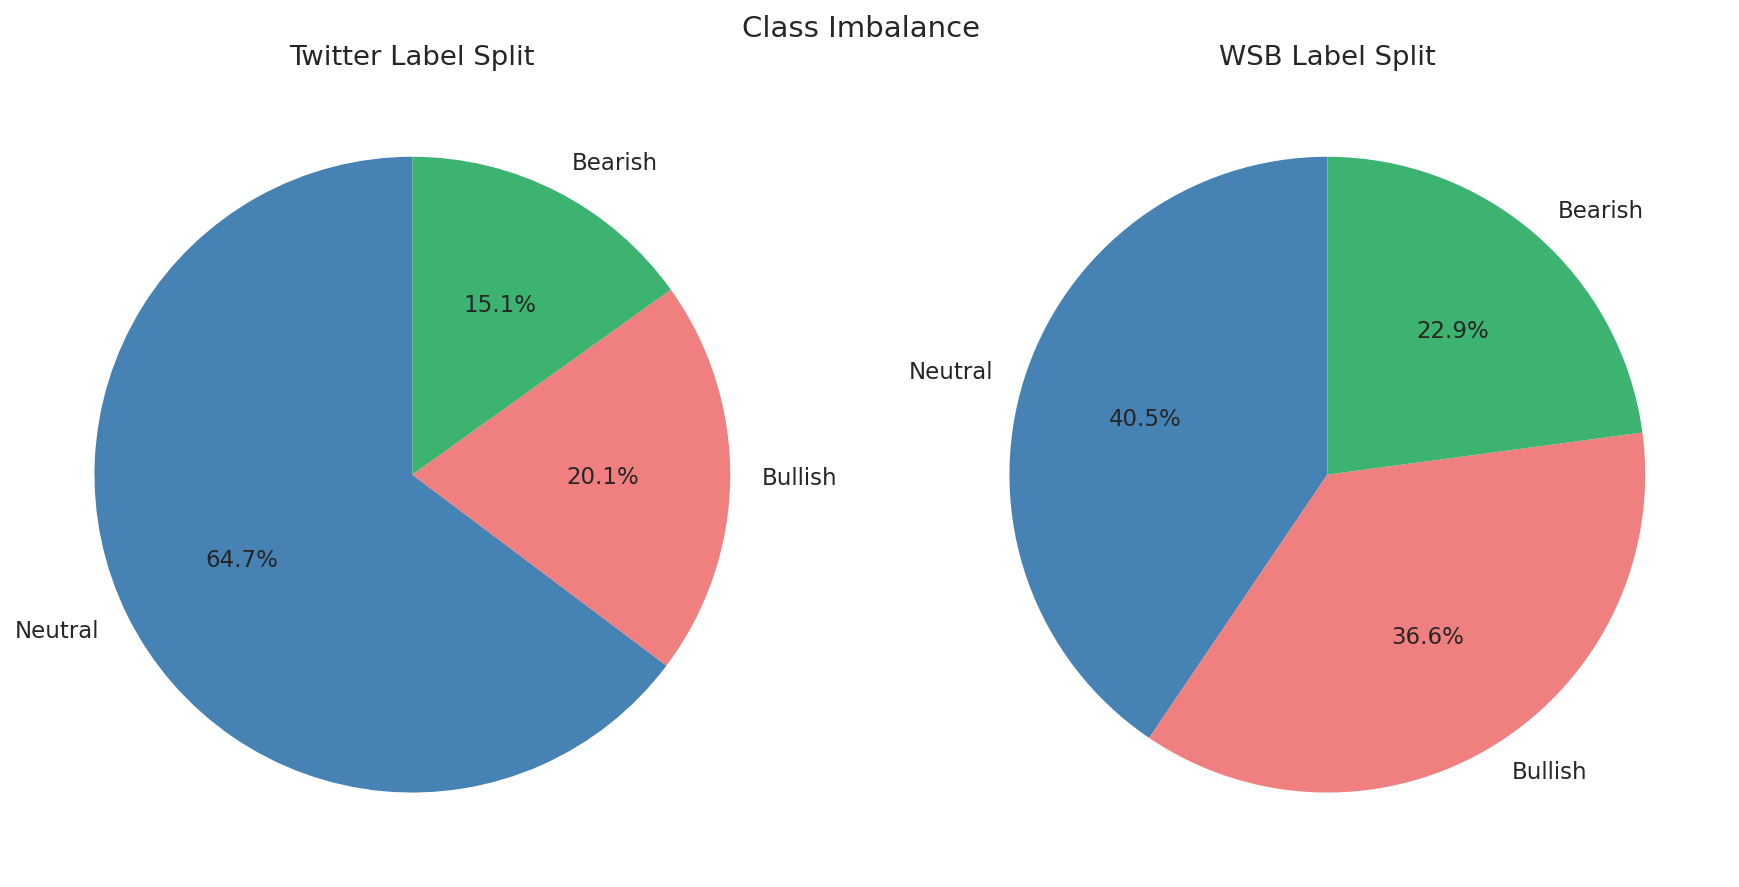

In [57]:
## Class imbalance plot

twitter_label_counts = twitter_train_df["label"].value_counts()
wsb_label_counts = wsb_train_df["label"].value_counts()
labels = [ID2LABEL[2], ID2LABEL[1], ID2LABEL[0]]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Pie chart twitter
axes[0].pie(twitter_label_counts.values, labels=labels, colors=["steelblue", "lightcoral", "Mediumseagreen"],
            autopct="%1.1f%%", startangle=90)
axes[0].set_title("Twitter Label Split")

# Pie chart WSB
axes[1].pie(wsb_label_counts.values, labels=labels, colors=["steelblue", "lightcoral", "Mediumseagreen"],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("WSB Label Split")


plt.suptitle("Class Imbalance", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR,"class_imbalance_pie"),bbox_inches="tight")
plt.show()

The class distributions reveal a stark contrast between the two datasets. The Twitter dataset is heavily skewed toward Neutral (64.7%), with Bullish (20.1%) and Bearish (15.1%) as minority classes, Bearish being the most underrepresented at roughly 1:4 ratio relative to Neutral. The WSB dataset is considerably more balanced, with Neutral (40.5%), Bullish (36.6%) and Bearish (22.9%) distributions closer to uniform, reflecting the more opinion-driven nature of Reddit posts compared to curated financial news tweets.

Bearish is the minority class in both datasets, making it the most challenging class to predict. This consistent pattern across domains suggests bearish sentiment is genuinely less frequent in financial social media, rather than being an artifact of annotation bias.

These distributions confirm two modeling decisions: balanced class weights will be applied during training to prevent the model from defaulting to Neutral predictions, and macro F1 will be used as the primary evaluation metric to ensure equal weight is given to all three classes regardless of support.

#### Text statistics

In [29]:
## Distribution of character and words in the twitter dataset

## Character distribution
print(f"Character distribution in the twitter train set:\n{twitter_train_df["text"].str.len().describe()}")

## Word distribution
print(f"\nWord distribution in the twitter train set:\n{twitter_train_df["text"].str.split().str.len().describe()}")

Character distribution in the twitter train set:
count    8588.000000
mean       85.836050
std        35.230818
min         2.000000
25%        58.000000
50%        79.000000
75%       120.000000
max       190.000000
Name: text, dtype: float64

Word distribution in the twitter train set:
count    8588.000000
mean       12.175128
std         4.682596
min         1.000000
25%         9.000000
50%        11.000000
75%        15.000000
max        32.000000
Name: text, dtype: float64


In [30]:
## Distribution of character and words in the WSB dataset

## Character distribution
print(f"Character distribution in the WSB train set:\n{wsb_train_df["text"].str.len().describe()}")

## Word distribution
print(f"\nWord distribution in the WSB train set:\n{wsb_train_df["text"].str.split().str.len().describe()}")

Character distribution in the WSB train set:
count    1088.000000
mean       46.504596
std        41.808055
min         4.000000
25%        20.000000
50%        32.000000
75%        56.000000
max       301.000000
Name: text, dtype: float64

Word distribution in the WSB train set:
count    1088.000000
mean        8.874081
std         7.759242
min         1.000000
25%         4.000000
50%         6.000000
75%        11.000000
max        56.000000
Name: text, dtype: float64


The text statistics reveal differences between the two domains. Twitter financial news posts are consistently longer, averaging 86 characters and 12 words, with relatively low variance (std=4.7 words), reflecting the structured, curated nature of financial news tweets which tend to follow a consistent format. The distribution is fairly compact with 75% of posts under 120 characters and 15 words.

WSB posts are shorter on average (47 characters, 9 words) but with substantially higher variance (std=7.8 words) and a long tail reaching 301 characters and 56 words. The median of just 6 words suggests WSB posts are often very short exclamations or reactions, while the high standard deviation indicates a mix of brief meme-style posts and longer opinion pieces. This high variance is characteristic of informal Reddit discourse.
Both datasets are well within the MAX_LEN=128 token limit, Twitter's maximum of 32 words and WSB's maximum of 56 words will tokenize comfortably within 128 subword tokens in almost all cases. This will be confirmed in the token length analysis below.

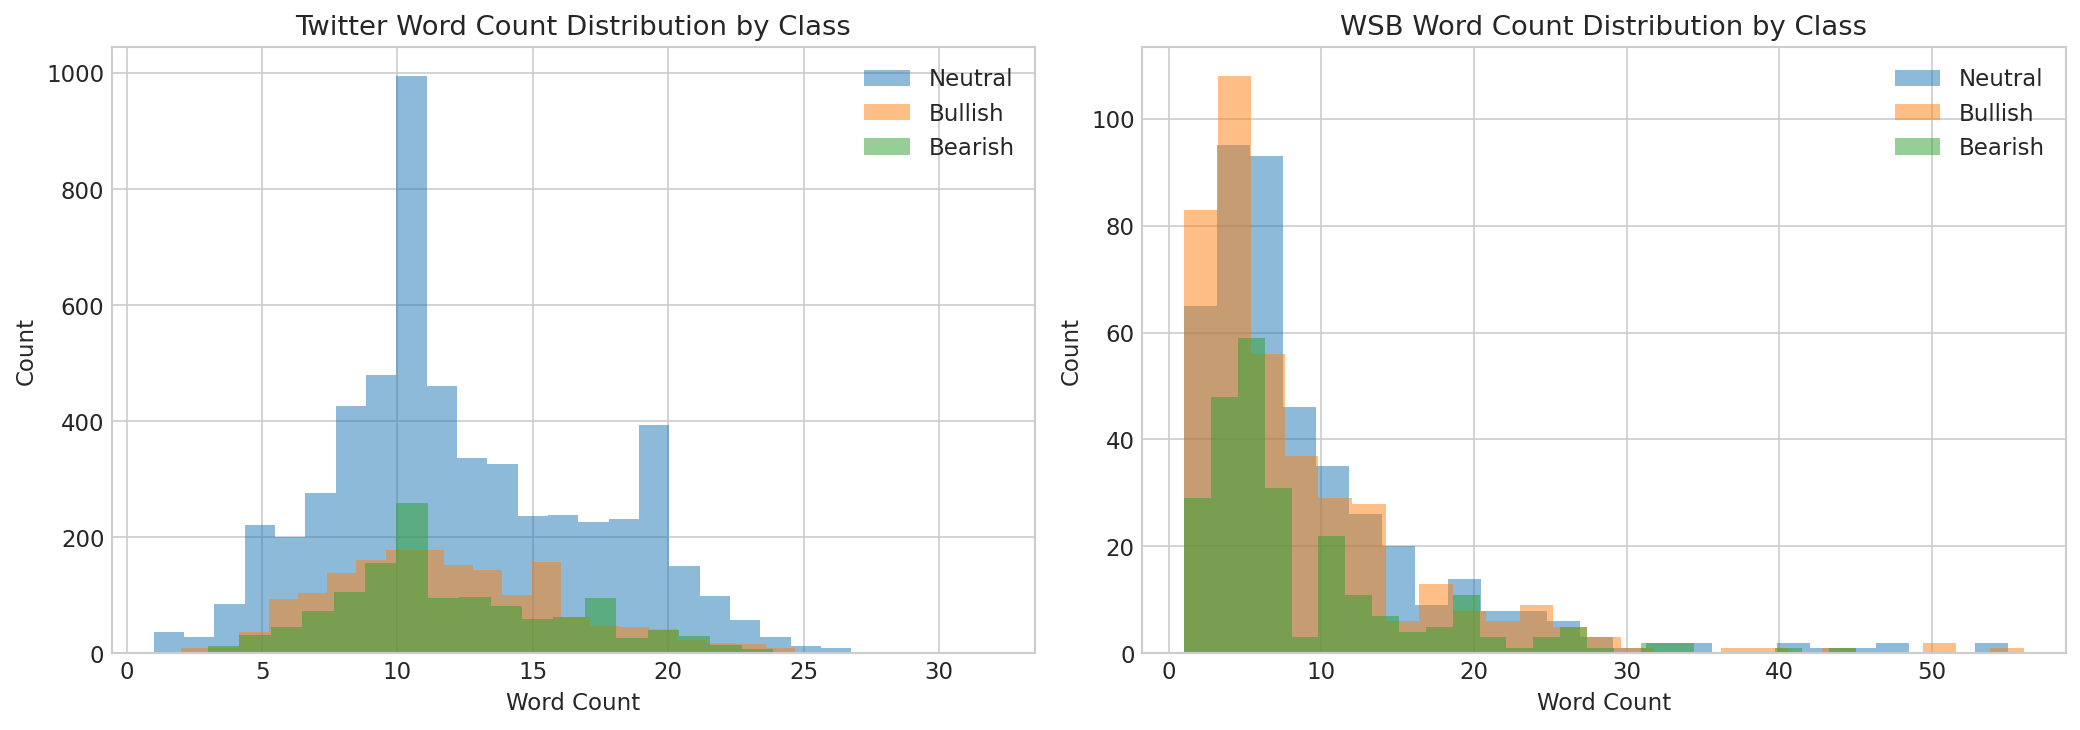

In [107]:
## Word Distribution plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in zip(axes,
                          [twitter_train_df, wsb_train_df],
                          ["Twitter", "WSB"]):
    for label_id, label_name in ID2LABEL.items():
        subset = df[df["label"] == label_id]["text"].str.split().str.len()
        ax.hist(subset, alpha=0.5, label=label_name, bins=25)
    ax.set_title(f"{title} Word Count Distribution by Class")
    ax.set_xlabel("Word Count")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR,"word_distribution"),bbox_inches="tight")
plt.show()

Word count distributions are strikingly similar across sentiment classes within each dataset, suggesting post length carries little sentiment signal. The key difference is between datasets: Twitter posts cluster tightly around 10-11 words reflecting structured news formatting, while WSB posts are shorter on average but with a pronounced right tail representing longer opinion pieces. This distributional difference is a quantitative indicator of the domain gap the models must bridge.

__Token length analysis__

In [88]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def get_token_lengths(texts):
    return [len(tokenizer.encode(text, add_special_tokens=True)) for text in texts]

twitter_token_lengths = get_token_lengths(twitter_train_df["text"].tolist())
wsb_token_lengths = get_token_lengths(wsb_train_df["text"].tolist())

In [89]:
print("The token statistics are as follows:")
print(f"Mean length for twitter: {np.mean(twitter_token_lengths):.2f} and for WSB: {np.mean(wsb_token_lengths):.2f}")
print(f"Median length for twitter: {np.median(twitter_token_lengths):.2f} and for WSB: {np.median(wsb_token_lengths):.2f}")
print(f"Max length for twitter: {np.max(twitter_token_lengths):.2f} and for WSB: {np.max(wsb_token_lengths):.2f}")
print(f"Min length for twitter: {np.min(twitter_token_lengths):.2f} and for WSB: {np.min(wsb_token_lengths):.2f}")

The token statistics are as follows:
Mean length for twitter: 27.65 and for WSB: 14.24
Median length for twitter: 25.00 and for WSB: 11.00
Max length for twitter: 82.00 and for WSB: 97.00
Min length for twitter: 3.00 and for WSB: 3.00


Token lengths were computed using the DistilBERT WordPiece tokenizer to validate the MAX_LEN=128 configuration. Twitter posts average 28 tokens (median=25) while WSB posts are shorter at 14 tokens (median=11), consistent with the word count analysis. Critically, the maximum token length across both datasets is 97 tokens, meaning MAX_LEN=128 covers 100% of both datasets with no truncation. Given this finding MAX_LEN is set to 100 to provide a small safety margin while reducing unnecessary padding overhead.

#### Text sample inspection

In [84]:
## Label example inspection for twitter

pd.set_option('display.max_colwidth', None)
for label_id, label_name in ID2LABEL.items():
    print(f"\n--- {label_name} ---")
    display(twitter_train_df[twitter_train_df["label"] == label_id][["text"]].sample(5, random_state=26))
pd.reset_option('display.max_colwidth')


--- Neutral ---


,text
8439,IVE : Strategic Acquisition of Salmat Marketing Solutions #IVE #Stock #MarketScreener https://t.co/34RQHqBr4Q https://t.co/pb1Q0Tkd1p
1455,Broadridge acquires Clearstructure Financial Technology
5806,Senate to vote on calling witnesses in Trump impeachment https://t.co/xAUA1gGpXv
810,Renascor Resources : Expiry of Unlisted Options #RenascorResources #Stock #MarketScreener https://t.co/zX9UuLOB1Z https://t.co/em7Rvh6Evk
7086,"Fed's Mester would have preferred no rate cuts in July, September"



--- Bullish ---


,text
5451,Wells still bullish on T-Mobile after unsurprising CEO change
237,Blockbusters like ‘Frozen 2’ will make Disney the first studio to earn $10 billion at the global box office in a si… https://t.co/4e8v3Uo3E4
96,FDA OKs Intercept’s NDA for obeticholic acid; shares up 5% premarket
7688,$AVLR - Avalara: Buy This Leader In The Tax Automation Trend. https://t.co/lqeMIiPUxZ #economy #stockmarket #markets
1388,Hedge Funds Have Never Been This Bullish On NVE Corporation (NVEC)



--- Bearish ---


,text
7460,"The reveal of the Tesla $TSLA #Cybertruck didn't go quite as expected... but moving on, there's a few specs you sho… https://t.co/wYnwjcjnEF"
7403,EUR/USD Weekly Price Forecast – Euro Slams Into Major Resistance
1517,$KRG: Compass Point cuts to Sell https://t.co/MCyfTsXc2N
2573,Gold Falls After Strong Jobless Report #Silver #Stock #MarketScreener https://t.co/sgJSZrfvJE https://t.co/JZ5Pu0GTuN
7677,UPDATE 1-Brazil's real posts lowest ever close of 4.2061 per dollar


In [87]:
## Label example inspection for WSB

pd.set_option('display.max_colwidth', None)
for label_id, label_name in ID2LABEL.items():
    print(f"\n--- {label_name} ---")
    display(wsb_train_df[wsb_train_df["label"] == label_id][["text"]].sample(5, random_state=26))
pd.reset_option('display.max_colwidth')


--- Neutral ---


,text
425,I think its time to sell
629,Zomedica now????
508,"GME? PLTR? No, this is the way."
548,Google workers announce plans to unionize.
1019,Can I still purchase fractional shares on other broker sites?



--- Bullish ---


,text
980,HACK THE MOON!
1251,NIO to the mOon!!!!! TD blocked everything!!!
1134,When will they realise? We CANNOT lose! Why? because we're not scared of losing a single. damn. dollar. You can't beat someone who is already beaten.
967,LET'S GO TO THE MOON
1487,LETS GOOOOO



--- Bearish ---


,text
840,So I guess they won?
1293,Good Bye And Thank You For all the Fish $NKLA Tards - Buying The Stonk Up To $39 When GM Dropped Them
307,What the fuck do I do
257,idk what to do now..
1208,FUCK THOSE WALL STREET HEDGE FUNDS!!!


The qualitative difference between the two domains is immediately apparent. Twitter financial news posts are structured, grammatically correct and news-like, they reference specific companies, financial metrics and market events in complete sentences. Sentiment is expressed through factual framing ("cuts to Sell", "shares up 5%", "slams into major resistance").

WSB posts are strikingly different in register. Bullish sentiment manifests as short exclamations ("HACK THE MOON!", "LETS GOOOOO"), heavy use of caps lock and repeated characters as emphasis markers. Bearish sentiment is often expressed through frustration and profanity ("FUCK THOSE WALL STREET HEDGE FUNDS!!!", "What the fuck do I do") rather than analytical language. Neutral posts are ambiguous and context-dependent, "I think its time to sell" could be bearish in another annotation scheme.

This qualitative contrast motivates the core research question: a model fine-tuned on structured financial Twitter text must adapt to a fundamentally different linguistic register to perform well on WSB data. Standard financial NLP vocabulary ("bullish", "cuts to Sell", "resistance") gives way to meme language, emotional outbursts and community-specific references.

#### Word cloud

In [90]:
## Clean function to get a clean word cloud

def clean_text_for_wordcloud(text):
    text = emoji.replace_emoji(text, replace='')  # remove emojis
    text = re.sub(r'http\S+', '', text)           # remove URLs
    text = re.sub(r'@\w+', '', text)              # remove mentions
    text = re.sub(r'\$[A-Z]+', '', text)          # remove tickers
    text = re.sub(r'#\w+', '', text)              # remove hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text)       # remove punctuation/numbers
    text = text.lower().strip()
    return text

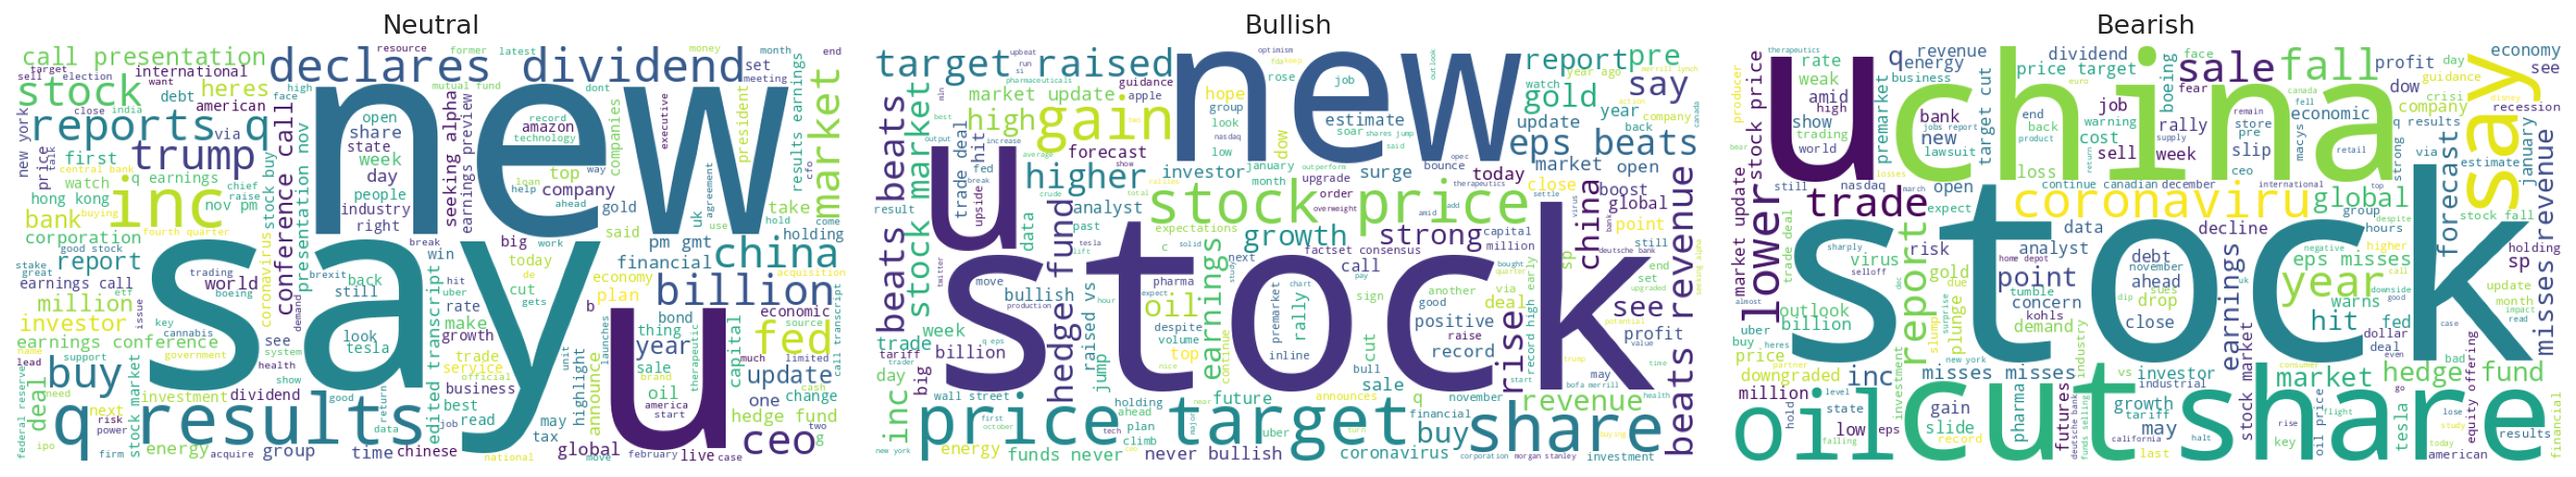

In [104]:
## word cloud for twitter

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (label, name) in zip(axes, ID2LABEL.items()):
    
    text = ' '.join(twitter_train_df[twitter_train_df['label'] == label]['text'].apply(clean_text_for_wordcloud))
    
    words = [word for word in text.split() if word not in stop_words]
    text_clean = ' '.join(words)
    
    # Generate wordcloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_clean)
    
    ax.imshow(wordcloud)
    ax.axis('off')
    ax.set_title(name)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "word_cloud_twitter.png"),bbox_inches="tight")
plt.show()

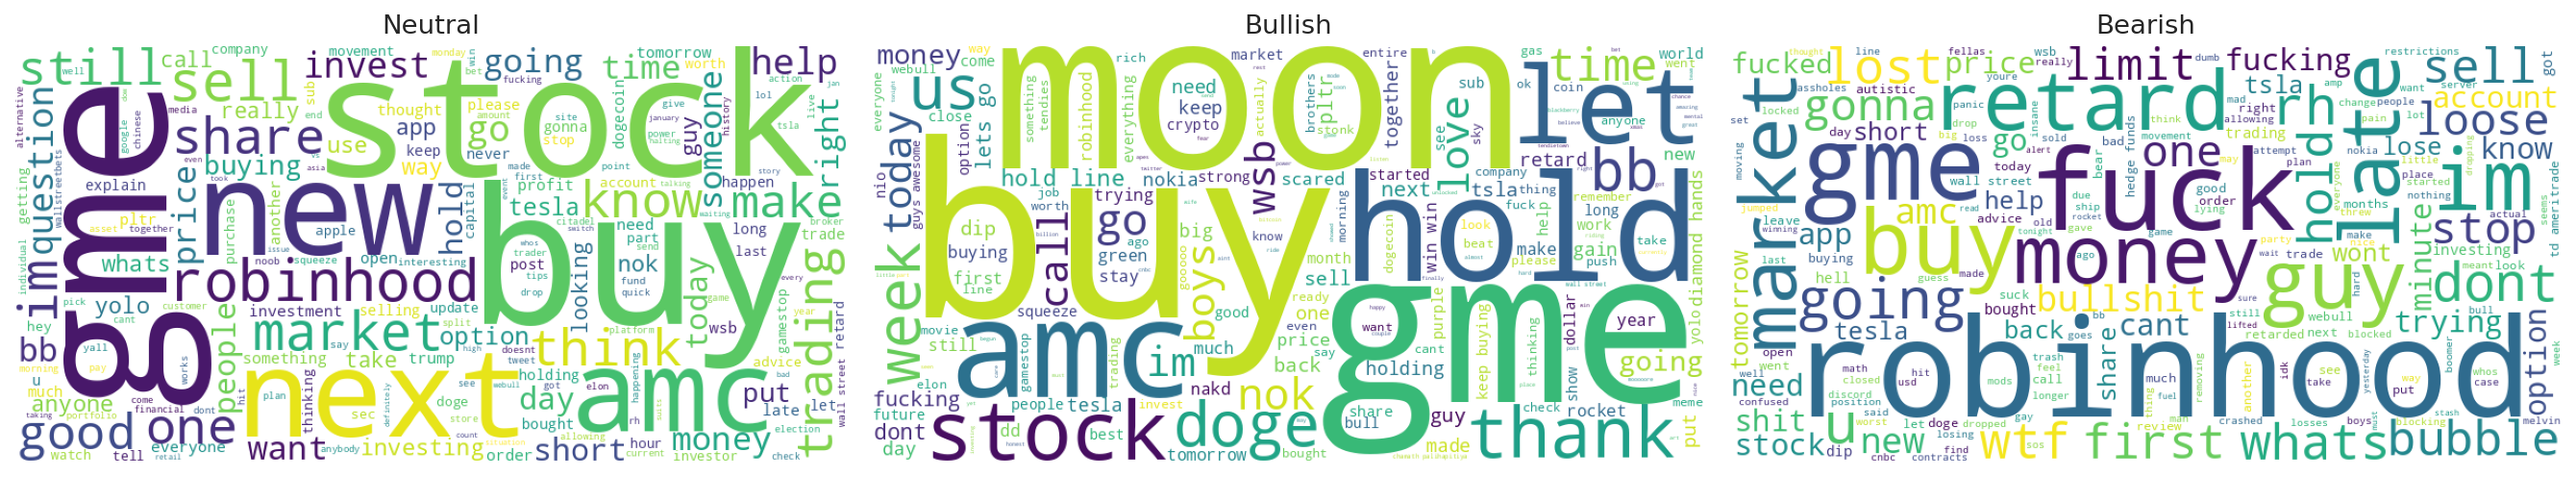

In [106]:
## word cloud for WSB

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (label, name) in zip(axes, ID2LABEL.items()):
    
    text = ' '.join(wsb_train_df[wsb_train_df['label'] == label]['text'].apply(clean_text_for_wordcloud))
    
    words = [word for word in text.split() if word not in stop_words]
    text_clean = ' '.join(words)
    
    # Generate wordcloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_clean)
    
    ax.imshow(wordcloud)
    ax.axis('off')
    ax.set_title(name)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "word_cloud_wsb.png"),bbox_inches="tight")
plt.show()

The word clouds visually confirm the domain gap observed in the sample examples.

Twitter word clouds are dominated by formal financial vocabulary consistent across all three classes: "stock", "share", "market", "earnings", "revenue", "price". Sentiment differentiation is subtle: Bullish posts feature words like "gain", "higher", "beats", "target" and "raise", while Bearish posts show "fall", "cut", "lower", "loss", "misses" and notably "coronavirus". Neutral posts are characterized by corporate announcements, "results", "dividend", "declares", "report". The vocabulary is professional and domain-specific throughout.

WSB word clouds reveal a starkly different linguistic universe. Bullish sentiment is expressed through meme language: "moon", "gme", "amc", "yolo", "diamond hands", "rocket", reflecting the community's retail investor culture during the 2021 GameStop short squeeze period. Bearish posts are emotionally charged, featuring profanity, "retard", "wtf", "bubble", "lose" and "robinhood", suggesting bearish sentiment in WSB is often tied to personal loss rather than analytical judgment. Neutral posts show community interaction vocabulary, "buy", "next", "market", "think", "know", reflecting the question-and-answer nature of neutral WSB posts.

This contrast has direct implications for domain transfer: a model trained on Twitter's formal financial vocabulary must generalize to WSB's meme-driven, emotionally charged register where sentiment markers are fundamentally different.

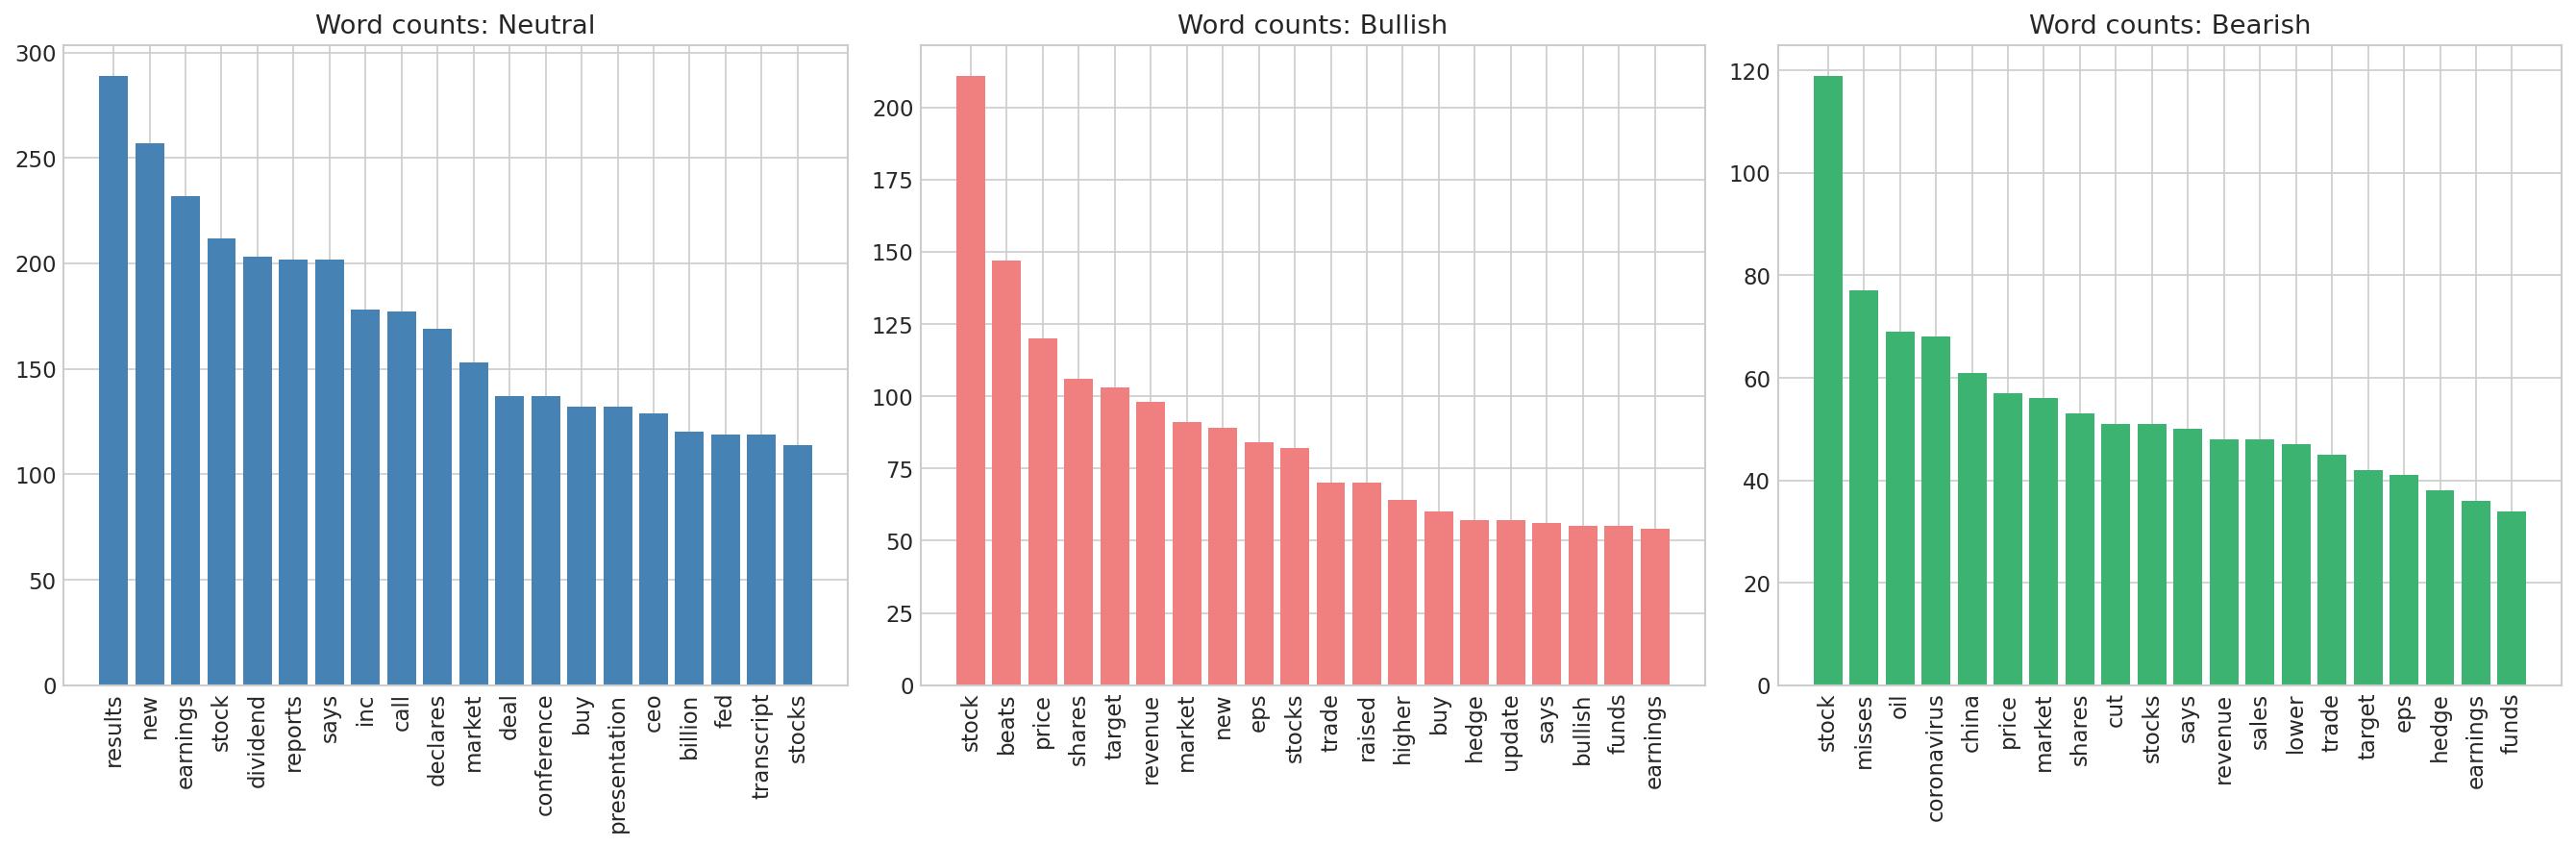

In [116]:
## Word count by class for twitter

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors={2:"steelblue", 1:"lightcoral", 0:"Mediumseagreen"}

for ax, (label, name) in zip(axes, ID2LABEL.items()):
    
    text = ' '.join(twitter_train_df[twitter_train_df['label'] == label]['text'].apply(clean_text_for_wordcloud))
    
    words = [word for word in text.split() if word not in stop_words and len(word) > 2]
    counter = Counter(words)
    words, counts = zip(*counter.most_common(20))
    ax.bar(words,counts,color=colors[label])
    ax.tick_params(axis='x', rotation=90)
    ax.set_title(f"Word counts: {ID2LABEL[label]}")

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "Word_count_bar_twitter.png"),bbox_inches="tight")
plt.show()

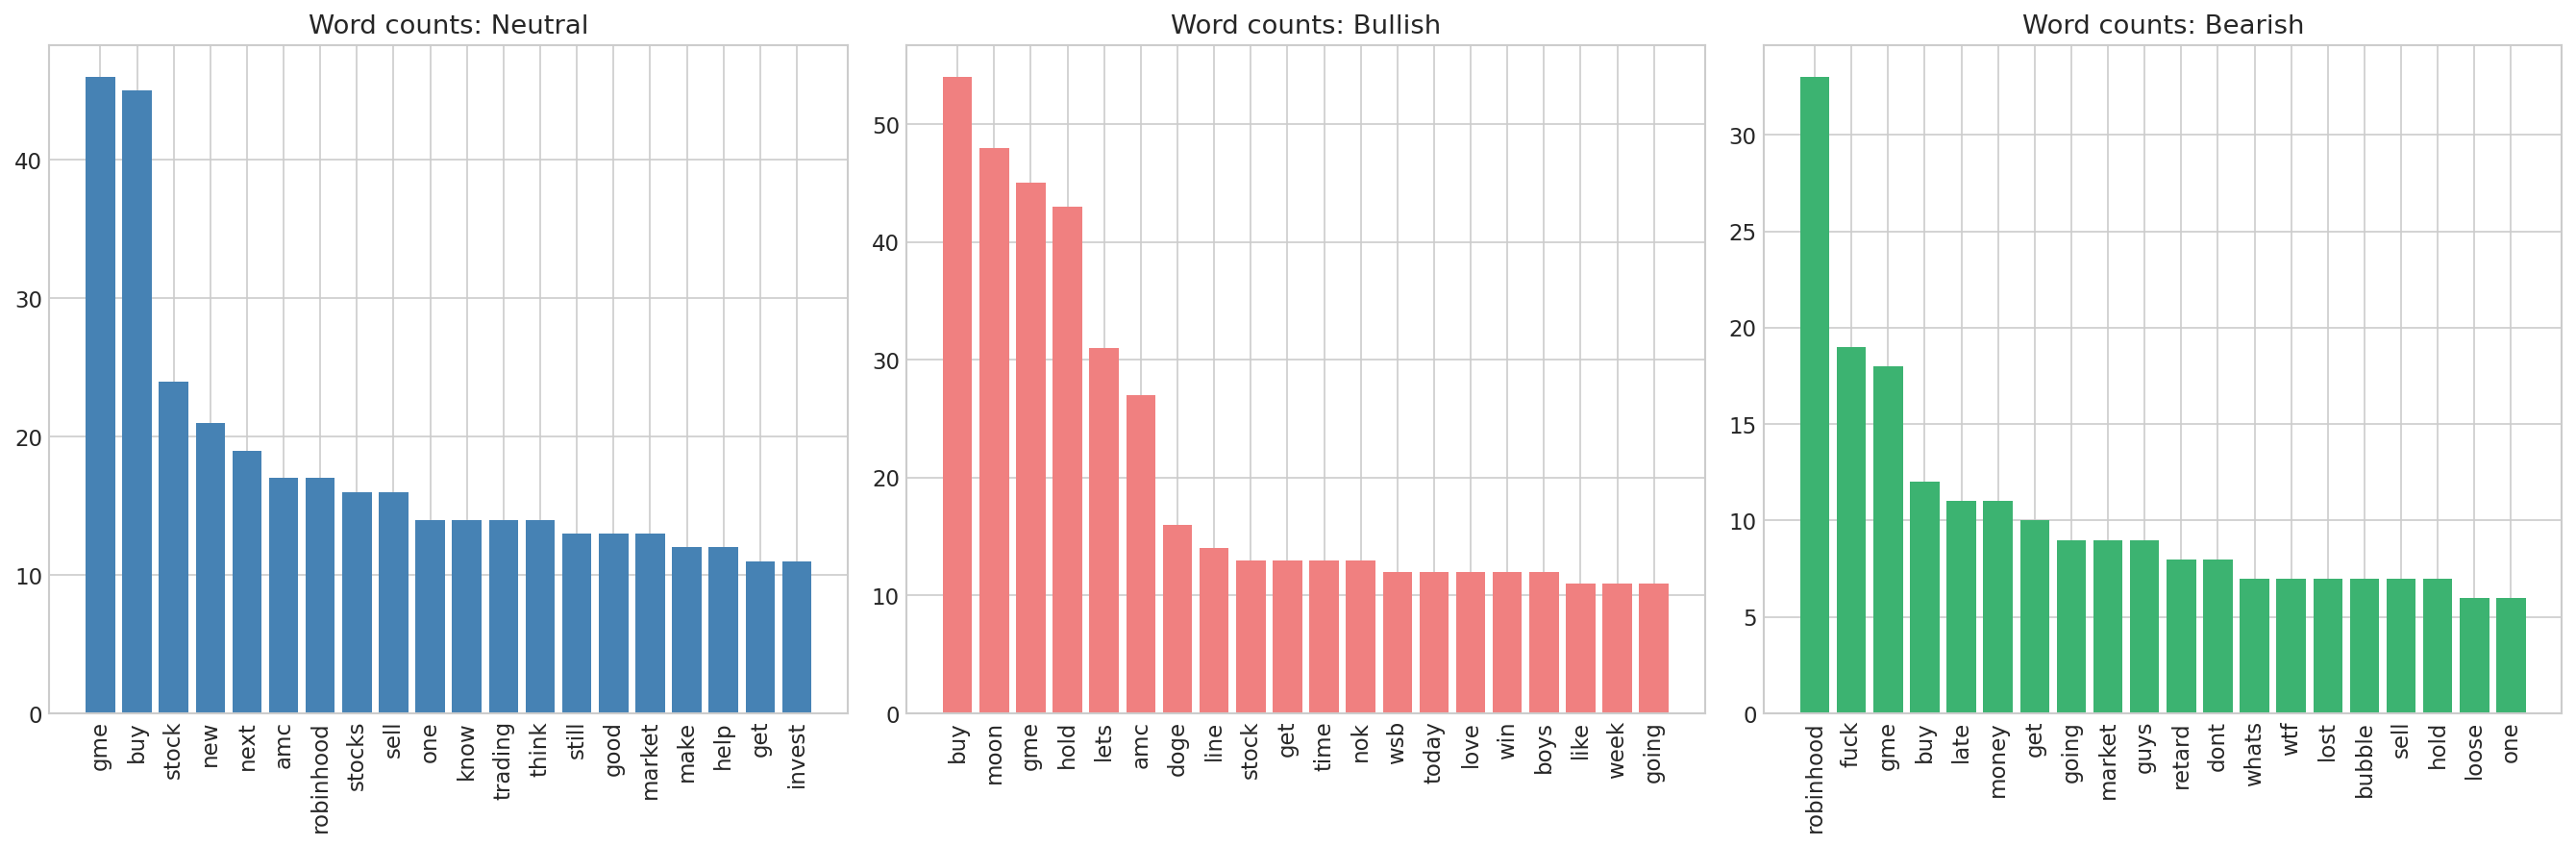

In [117]:
## Word count by class for WSB

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors={2:"steelblue", 1:"lightcoral", 0:"Mediumseagreen"}

for ax, (label, name) in zip(axes, ID2LABEL.items()):
    
    text = ' '.join(wsb_train_df[wsb_train_df['label'] == label]['text'].apply(clean_text_for_wordcloud))
    
    words = [word for word in text.split() if word not in stop_words and len(word) > 2]
    counter = Counter(words)
    words, counts = zip(*counter.most_common(20))
    ax.bar(words,counts,color=colors[label])
    ax.tick_params(axis='x', rotation=90)
    ax.set_title(f"Word counts: {ID2LABEL[label]}")

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "Word_count_bar_wsb.png"),bbox_inches="tight")
plt.show()

The word frequency analysis reinforces the domain gap observed in the word clouds and provides additional sentiment signal insights.

Twitter shows clear sentiment-discriminative vocabulary. Bullish posts are characterized by performance indicators: "beats", "target", "raised", "higher", "revenue", reflecting positive earnings surprises and price targets. Bearish posts feature loss indicators: "misses", "cut", "lower", "sales", "coronavirus", with "misses" as the dominant term suggesting earnings disappointments drive bearish sentiment. Neutral posts are dominated by corporate event vocabulary: "results", "earnings", "declares", "dividend", "conference", "transcript", consistent with factual announcements carrying no directional sentiment.

WSB tells a different story. Bullish posts are dominated by meme stocks: "buy", "moon", "gme", "hold", "amc", "doge", reflecting the community's retail trading culture. Bearish posts are led by "robinhood" and "fuck", suggesting bearish sentiment is strongly tied to the Robinhood trading restrictions during the GameStop event. Neutral posts show community interaction words: "gme", "buy", "think", "know", "next", indicating that even neutral WSB posts revolve around the same meme stock universe.

## Tokenization

No text cleaning is applied prior to tokenization. DistilBERT's WordPiece tokenizer is designed to handle raw social media text including URLs, punctuation and informal language. The cleaning function defined before word cloud is used exclusively for EDA visualizations and is not applied to model inputs. Only the trailing and leading whitespaces are stripped.

In [20]:
# only strip leading/trailing whitespace

for df in [twitter_train_df, twitter_val_df, twitter_test_df,wsb_train_df, wsb_val_df, wsb_test_df]:
    df["text"] = df["text"].str.strip()

In [21]:
## Convert the pandas dataframe back to huggingface dataset

twitter_train_hf = Dataset.from_pandas(twitter_train_df, preserve_index=False)
twitter_val_hf = Dataset.from_pandas(twitter_val_df, preserve_index=False)
twitter_test_hf = Dataset.from_pandas(twitter_test_df, preserve_index=False)
wsb_train_hf = Dataset.from_pandas(wsb_train_df, preserve_index=False)
wsb_val_hf = Dataset.from_pandas(wsb_val_df, preserve_index=False)
wsb_test_hf = Dataset.from_pandas(wsb_test_df, preserve_index=False)

In [25]:
## Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(example: dict) -> dict:
    """Tokenize a single example using DistilBERT tokenizer with truncation.
    Padding is handled dynamically at batch level by DataCollatorWithPadding."""
    return tokenizer(
        example['text'],
        max_length=MAX_LEN,
        truncation=True
    )

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
# Apply to datasets
splits = [twitter_train_hf, twitter_val_hf, twitter_test_hf,wsb_train_hf, wsb_val_hf, wsb_test_hf]

splits = [s.map(tokenize, batched=True) for s in splits]
splits = [s.rename_column('label', 'labels') for s in splits]
for s in splits:
    s.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

Map:   0%|          | 0/8588 [00:00<?, ? examples/s]

Map:   0%|          | 0/955 [00:00<?, ? examples/s]

Map:   0%|          | 0/2388 [00:00<?, ? examples/s]

Map:   0%|          | 0/1088 [00:00<?, ? examples/s]

Map:   0%|          | 0/193 [00:00<?, ? examples/s]

Map:   0%|          | 0/321 [00:00<?, ? examples/s]

In [23]:
## Checking an example

print(splits[0][0])
print(splits[3][0])

{'labels': tensor(0), 'input_ids': tensor([  101,  6090,  3207,  7712,  3475,  1005,  1056,  1037, 23264,  2005,
         7954,  6959,  9786,  1001,  4610,  1001,  6089, 24410,  2121, 16770,
         1024,  1013,  1013,  1056,  1012,  2522,  1013, 25212,  2243, 22394,
        10736,  2232,  2595,  2480, 16770,  1024,  1013,  1013,  1056,  1012,
         2522,  1013, 10710, 13871, 28311,  5937,  2683,   102]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}
{'labels': tensor(1), 'input_ids': tensor([  101,  2298,  2054,  3662,  2039,   999,  1059, 19022,  2003,  1996,
         2327,  9226, 20285, 17695,  1006,  1996,  3976,  2017,  2156,  2003,
        13938,  2063,  4518,  3976,  1007,  1024, 17070,  1024,  1024,  2992,
         1035,  2192,  1024,  1024,  7596,  1024,   102]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

## Training

In [30]:
## Define custom trainer to deal with class imbalance

class WeightedTrainer(Trainer):
    """Custom Trainer that applies class weights to the loss function to handle class imbalance."""
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """Compute weighted cross entropy loss."""
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)(logits, labels)
        return (loss, outputs) if return_outputs else loss

### Experiment 1: DistilBERT Fine-tuned on Twitter

In this experiment we fine-tune DistilBERT on the Twitter Financial News Sentiment training set and evaluate on both the Twitter test set and the WSB test set. This establishes two baselines simultaneously:

In-domain performance: how well the model performs on Twitter data it was trained on
Zero-shot cross-domain transfer: how well a Twitter-trained model performs on WSB without any WSB training data

The model is trained three times with different random seeds (26, 42, 74) to account for training variance. We report mean and standard deviation across seeds for all metrics. Class weights computed on the Twitter training set are applied to handle class imbalance.

#### Class weight calculation

In [29]:
## compute class weights on twitter training set only
twitter_labels = twitter_train_df["label"].values

class_weights = compute_class_weight(class_weight="balanced",classes=np.unique(twitter_labels),y=twitter_labels)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

for class_id, weight in zip(np.unique(twitter_labels), class_weights):
    print(f"  {ID2LABEL[class_id]}: {weight:.3f}")

  Bearish: 2.205
  Bullish: 1.655
  Neutral: 0.515


Class weights are computed using sklearn's balanced weighting scheme on the Twitter training set. Bearish receives the highest weight (2.205) reflecting its underrepresentation at 15% of the training data, while Neutral is downweighted (0.515) to prevent the model from defaulting to majority class predictions. Weights will be recomputed on the combined Twitter+WSB training set later.

In [30]:
## Define metrics to evaluate model

def compute_metrics(eval_pred) -> dict:
    """Compute weighted F1 and accuracy for evaluation."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "f1_macro": f1_score(labels, predictions, average="macro"),
        "f1_weighted": f1_score(labels, predictions, average="weighted"),
        "accuracy": accuracy_score(labels, predictions)
    }

#### Trainer

In [36]:
## Setting up model and training arguments
results_exp1 = []

for seed in SEEDS:

    set_seed(seed)
    
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3,id2label=ID2LABEL,label2id=LABEL2ID)
    
    os.makedirs(os.path.join(CHECKPOINT_DIR, f"exp1_seed{seed}"), exist_ok=True)
    
    training_args = TrainingArguments(
        output_dir= os.path.join(CHECKPOINT_DIR, f"exp1_seed{seed}"),
        num_train_epochs= 3,
        per_device_train_batch_size= BATCH_SIZE,
        per_device_eval_batch_size= BATCH_SIZE,
        learning_rate= LEARNING_RATE,
        weight_decay= WEIGHT_DECAY,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end= True,
        metric_for_best_model= EVAL_METRIC,
        fp16=True,
        logging_dir= LOGGING_DIR,
        logging_steps=50,
        warmup_ratio=WARMUP_RATIO,
        save_total_limit=1,
        seed=seed,
        report_to="none",
        run_name=f"distilbert_twitter_only_seed{seed}",
        greater_is_better=True,
    )
    
    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=splits[0],
        eval_dataset=splits[1],
        compute_metrics=compute_metrics,
        data_collator=data_collator,
    )
    
    trainer.train()

    predictions = trainer.predict(splits[2])
    
    logits = predictions.predictions
    predicted_class = np.argmax(logits, axis =-1)
    true_label = predictions.label_ids

    report = classification_report(true_label, predicted_class, target_names=list(LABEL2ID.keys()),output_dict=True)
    results_exp1.append(
        {"seed": seed,
        "twitter_f1_macro": report["macro avg"]["f1-score"],
        "twitter_f1_weighted": report["weighted avg"]["f1-score"],
        "twitter_accuracy": report["accuracy"]
    })
    
with open(os.path.join(RESULTS_DIR, "exp1_results.json"), "w") as f:
    json.dump(results_exp1, f, indent=2)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Accuracy
1,0.545422,0.576861,0.758978,0.811233,0.805236
2,0.382301,0.558268,0.785819,0.828370,0.825131
3,0.291017,0.629642,0.793527,0.837869,0.835602


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Accuracy
1,0.571943,0.612538,0.744416,0.801551,0.794764
2,0.389561,0.570280,0.788857,0.835545,0.832461
3,0.282298,0.603924,0.804244,0.847809,0.846073


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


In [40]:
metrics = ["twitter_f1_macro", "twitter_f1_weighted", "twitter_accuracy"]
print("Experiment 1 DistilBERT fine-tuned on Twitter (Twitter test set)")
print("-" * 60)
for metric in metrics:
    values = [r[metric] for r in results_exp1]
    print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

Experiment 1L DistilBERT fine-tuned on Twitter (Twitter test set)
------------------------------------------------------------
twitter_f1_macro: 0.8361 ± 0.0030
twitter_f1_weighted: 0.8729 ± 0.0027
twitter_accuracy: 0.8710 ± 0.0029


DistilBERT fine-tuned on Twitter Financial News achieves a mean macro F1 of 0.836 on the in-domain Twitter test set, with remarkably low variance across seeds (std=0.003), indicating stable and reproducible training dynamics. This serves as our in-domain performance ceiling, the best we can expect from a model trained and evaluated on the same domain.

The gap between macro F1 (0.836) and weighted F1 (0.873) reflects residual difficulty on the Bearish minority class despite class weighting. Per-class F1 scores and confusion matrices are presented below.

This result will serve as the reference point for all subsequent experiments. Any degradation observed when evaluating on WSB or StockTwits data quantifies the domain transfer cost.

In [29]:
for seed in SEEDS:
    path = os.path.join(CHECKPOINT_DIR, f"exp1_seed{seed}")
    print(os.listdir(path))

['checkpoint-1611']
['checkpoint-1611']
['checkpoint-1611']


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

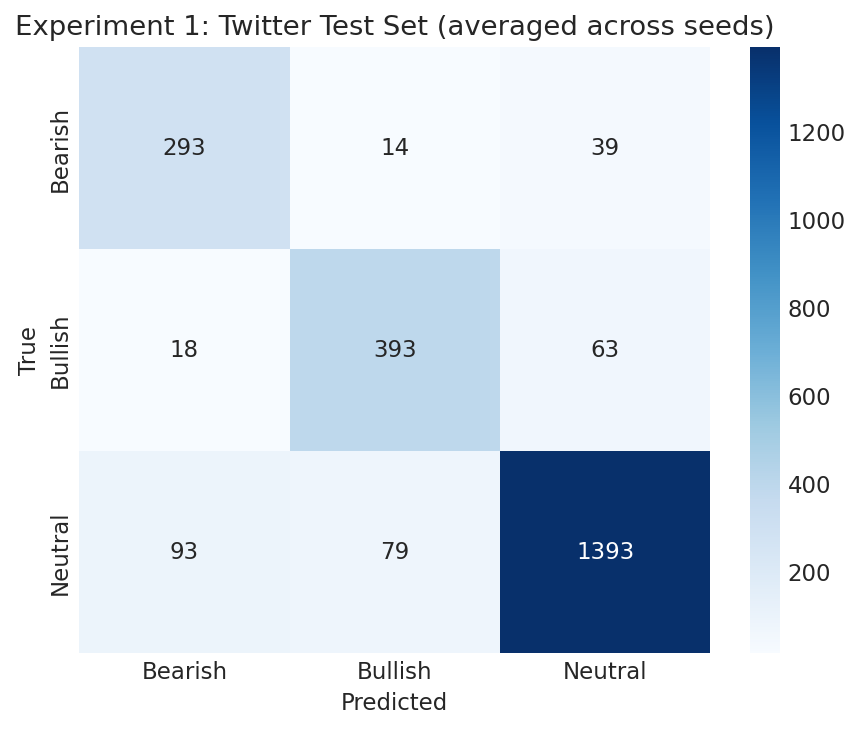

In [31]:
## Confusion matrix
cms = []

for seed in SEEDS:
    set_seed(seed)
    path = os.path.join(CHECKPOINT_DIR, f"exp1_seed{seed}")
    model = AutoModelForSequenceClassification.from_pretrained(os.path.join(path, "checkpoint-1611"))
    training_args = TrainingArguments(
        output_dir= path,
        per_device_eval_batch_size=BATCH_SIZE,
        fp16=True,
        report_to="none"
    )
    evaluator = WeightedTrainer(
        model=model,
        args=training_args,
        compute_metrics=compute_metrics,
        data_collator=data_collator,
    )
    predictions = evaluator.predict(splits[2])
    logits = predictions.predictions
    predicted_class = np.argmax(logits, axis =-1)
    true_label = predictions.label_ids
    cm = confusion_matrix(true_label, predicted_class)
    cms.append(cm)

avg_cm = np.array(cms).mean(axis=0).astype(int)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(avg_cm, annot=True, fmt='d', 
            xticklabels=list(LABEL2ID.keys()),
            yticklabels=list(LABEL2ID.keys()),
            cmap='Blues')
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Experiment 1: Twitter Test Set (averaged across seeds)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "confusion_matrix_exp1_twitter_avg.png"), bbox_inches="tight")

#### Evaluating on the WSB test set

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

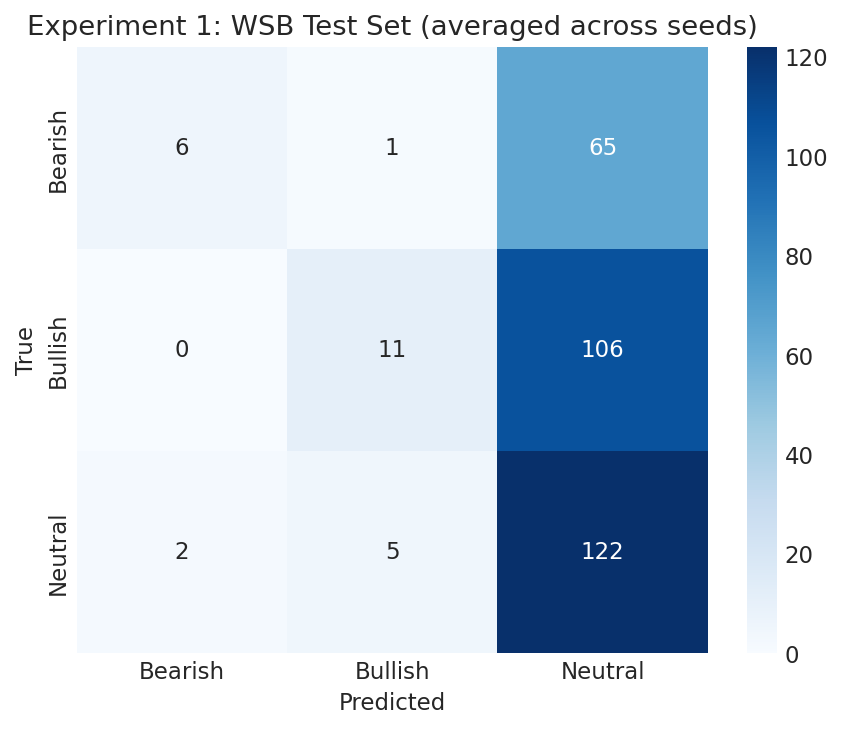

In [32]:
## WSB evaluation loop

results_exp1_wsb = []
cms = []
for seed in SEEDS:
    set_seed(seed)
    path = os.path.join(CHECKPOINT_DIR, f"exp1_seed{seed}")
    model = AutoModelForSequenceClassification.from_pretrained(os.path.join(path, "checkpoint-1611"))
    training_args = TrainingArguments(
        output_dir= path,
        per_device_eval_batch_size=BATCH_SIZE,
        fp16=True,
        report_to="none"
    )
    evaluator = WeightedTrainer(
        model=model,
        args=training_args,
        compute_metrics=compute_metrics,
        data_collator=data_collator,
    )
    predictions = evaluator.predict(splits[5])
    logits = predictions.predictions
    predicted_class = np.argmax(logits, axis =-1)
    true_label = predictions.label_ids
    report = classification_report(true_label, predicted_class, target_names=list(LABEL2ID.keys()),output_dict=True)
    results_exp1_wsb.append(
        {"seed": seed,
        "WSB_f1_macro": report["macro avg"]["f1-score"],
        "WSB_f1_weighted": report["weighted avg"]["f1-score"],
        "WSB_accuracy": report["accuracy"]
    })
    cm = confusion_matrix(true_label, predicted_class)
    cms.append(cm)
    
with open(os.path.join(RESULTS_DIR, "exp1_results_wsb.json"), "w") as f:
    json.dump(results_exp1_wsb, f, indent=2)

avg_cm = np.array(cms).mean(axis=0).astype(int)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(avg_cm, annot=True, fmt='d', 
            xticklabels=list(LABEL2ID.keys()),
            yticklabels=list(LABEL2ID.keys()),
            cmap='Blues')
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Experiment 1: WSB Test Set (averaged across seeds)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "confusion_matrix_exp1_WSB_avg.png"), bbox_inches="tight")

The confusion matrix reveals the precise failure mode: the Twitter-trained model collapses to predicting Neutral for virtually all WSB examples, correctly classifying only 6 Bearish and 11 Bullish posts out of 72 and 117 respectively. This is a direct consequence of the model learning Twitter's class distribution (65% Neutral) rather than sentiment-discriminative features that generalize across domains. The model has learned "when uncertain, predict Neutral", a strategy that works well in-domain but catastrophically fails on WSB where Neutral represents only 40% of examples.

In [33]:
metrics = ["WSB_f1_macro", "WSB_f1_weighted", "WSB_accuracy"]
print("Experiment 1 DistilBERT fine-tuned on Twitter (WSB test set)")
print("-" * 60)
for metric in metrics:
    values = [r[metric] for r in results_exp1_wsb]
    print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

Experiment 1 DistilBERT fine-tuned on Twitter (WSB test set)
------------------------------------------------------------
WSB_f1_macro: 0.2972 ± 0.0092
WSB_f1_weighted: 0.3278 ± 0.0074
WSB_accuracy: 0.4351 ± 0.0029


Evaluating the Twitter-trained model on the WSB test set reveals severe domain transfer failure. Macro F1 drops from 0.836 to 0.297, a 64% relative degradation, despite both datasets sharing the same label schema and financial subject matter. Accuracy of 0.435 is only marginally above random chance (0.333), indicating the model has learned Twitter-specific linguistic patterns that do not generalize to WSB's informal, meme-driven register.

This result establishes the domain gap quantitatively and motivates the subsequent experiment: does fine-tuning on WSB data recover performance?

### Experiment 2: DistilBERT Fine-tuned on Twitter + WSB

In this experiment we fine-tune DistilBERT on a combined training set consisting of the Twitter Financial News and WSB training data (9,676 examples total). The model is evaluated separately on both the Twitter test set and the WSB test set.

This experiment addresses two questions simultaneously:

- Domain adaptation: does exposure to WSB training data recover the severe performance degradation observed in Experiment 1?
- Catastrophic forgetting: does adding WSB data hurt in-domain Twitter performance?

The validation set remains the Twitter validation set for consistency with Experiment 1, ensuring training curves are directly comparable across experiments. Class weights are recomputed on the combined training set to reflect the shifted class distribution resulting from merging the two datasets.

The model is trained three times with different random seeds (26, 42, 74). Results are reported as mean ± standard deviation across seeds and compared directly against Experiment 1 baselines.

In [36]:
## Combinging the two train sets

combined_train = concatenate_datasets([splits[0], splits[3]]) 

#### Class weight calculation

In [37]:
## recompute class weights on combined training set

combined_labels = np.concatenate([twitter_train_df["label"].values, wsb_train_df["label"].values])

class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(combined_labels), y=combined_labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights (combined Twitter + WSB training set):")
for class_id, weight in zip(np.unique(combined_labels), class_weights):
    print(f"  {ID2LABEL[class_id]}: {weight:.3f}")

Class weights (combined Twitter + WSB training set):
  Bearish: 2.085
  Bullish: 1.516
  Neutral: 0.537


Class weights shift modestly compared to Experiment 1, Bearish decreases from 2.205 to 2.085 and Neutral increases from 0.515 to 0.537, reflecting the more balanced class distribution of the WSB data diluting Twitter's heavy Neutral skew.

In [38]:
## Define metrics to evaluate model

def compute_metrics(eval_pred) -> dict:
    """Compute weighted F1 and accuracy for evaluation."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "f1_macro": f1_score(labels, predictions, average="macro"),
        "f1_weighted": f1_score(labels, predictions, average="weighted"),
        "accuracy": accuracy_score(labels, predictions)
    }

#### Trainer

In [ ]:
## Setting up model and training arguments
results_exp2_twitter = []
results_exp2_wsb = []
cms_twitter = []
cms_wsb = []

for seed in SEEDS:

    set_seed(seed)
    
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3,id2label=ID2LABEL,label2id=LABEL2ID)
    
    os.makedirs(os.path.join(CHECKPOINT_DIR, f"exp2_seed{seed}"), exist_ok=True)
    
    training_args = TrainingArguments(
        output_dir= os.path.join(CHECKPOINT_DIR, f"exp2_seed{seed}"),
        num_train_epochs= EPOCHS,
        per_device_train_batch_size= BATCH_SIZE,
        per_device_eval_batch_size= BATCH_SIZE,
        learning_rate= LEARNING_RATE,
        weight_decay= WEIGHT_DECAY,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end= True,
        metric_for_best_model= EVAL_METRIC,
        fp16=True,
        logging_dir= LOGGING_DIR,
        logging_steps=50,
        warmup_ratio=WARMUP_RATIO,
        save_total_limit=1,
        seed=seed,
        report_to="none",
        run_name=f"distilbert_twitterAndWSB_seed{seed}",
        greater_is_better=True,
    )
    
    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=combined_train,
        eval_dataset=splits[1],
        compute_metrics=compute_metrics,
        data_collator=data_collator,
    )
    
    trainer.train()

    predictions = trainer.predict(splits[2])
    
    logits = predictions.predictions
    predicted_class = np.argmax(logits, axis =-1)
    true_label = predictions.label_ids
    cm = confusion_matrix(true_label, predicted_class)
    cms_twitter.append(cm)
    report = classification_report(true_label, predicted_class, target_names=list(LABEL2ID.keys()),output_dict=True)
    results_exp2_twitter.append(
        {"seed": seed,
        "twitter_f1_macro": report["macro avg"]["f1-score"],
        "twitter_f1_weighted": report["weighted avg"]["f1-score"],
        "twitter_accuracy": report["accuracy"]
    })

    predictions = trainer.predict(splits[5])
    
    logits = predictions.predictions
    predicted_class = np.argmax(logits, axis =-1)
    true_label = predictions.label_ids
    cm = confusion_matrix(true_label, predicted_class)
    cms_wsb.append(cm)
    report = classification_report(true_label, predicted_class, target_names=list(LABEL2ID.keys()),output_dict=True)
    results_exp2_wsb.append(
        {"seed": seed,
        "WSB_f1_macro": report["macro avg"]["f1-score"],
        "WSB_f1_weighted": report["weighted avg"]["f1-score"],
        "WSB_accuracy": report["accuracy"]
    })
    
with open(os.path.join(RESULTS_DIR, "exp2_results_twitter.json"), "w") as f:
    json.dump(results_exp2_twitter, f, indent=2)
with open(os.path.join(RESULTS_DIR, "exp2_results_wsb.json"), "w") as f:
    json.dump(results_exp2_wsb, f, indent=2)
    
avg_cm_twitter = np.array(cms_twitter).mean(axis=0).astype(int)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(avg_cm_twitter, annot=True, fmt='d', 
            xticklabels=list(LABEL2ID.keys()),
            yticklabels=list(LABEL2ID.keys()),
            cmap='Blues')
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Experiment 2: Twitter Test Set (averaged across seeds)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "confusion_matrix_exp2_twitter_avg.png"), bbox_inches="tight")

avg_cm_wsb = np.array(cms_wsb).mean(axis=0).astype(int)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(avg_cm_wsb, annot=True, fmt='d', 
            xticklabels=list(LABEL2ID.keys()),
            yticklabels=list(LABEL2ID.keys()),
            cmap='Blues')
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Experiment 2: WSB Test Set (averaged across seeds)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "confusion_matrix_exp2_wsb_avg.png"), bbox_inches="tight")

In [44]:
metrics = ["twitter_f1_macro", "twitter_f1_weighted", "twitter_accuracy"]
print("Experiment 2 DistilBERT fine-tuned on Twitter + WSB (Twitter test set)")
print("-" * 60)
for metric in metrics:
    values = [r[metric] for r in results_exp2_twitter]
    print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

Experiment 2 DistilBERT fine-tuned on Twitter + WSB (Twitter test set)
------------------------------------------------------------
twitter_f1_macro: 0.8287 ± 0.0046
twitter_f1_weighted: 0.8652 ± 0.0033
twitter_accuracy: 0.8621 ± 0.0037


In [45]:
metrics = ["WSB_f1_macro", "WSB_f1_weighted", "WSB_accuracy"]
print("Experiment 2 DistilBERT fine-tuned on Twitter + WSB (WSB test set)")
print("-" * 60)
for metric in metrics:
    values = [r[metric] for r in results_exp2_wsb]
    print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

Experiment 2 DistilBERT fine-tuned on Twitter + WSB (WSB test set)
------------------------------------------------------------
WSB_f1_macro: 0.7249 ± 0.0192
WSB_f1_weighted: 0.7322 ± 0.0191
WSB_accuracy: 0.7342 ± 0.0184


Fine-tuning on the combined Twitter + WSB dataset yields two key findings.

First, WSB performance recovers dramatically, macro F1 improves from 0.297 to 0.725, a 144% relative improvement, demonstrating that even a small amount of in-domain WSB data (1,088 training examples) is sufficient to bridge a large portion of the domain gap. 

Second, Twitter performance degrades only marginally from 0.836 to 0.829, a difference of 0.007 that falls within normal training variance, indicating no meaningful catastrophic forgetting. The model successfully adapts to WSB's informal register while retaining its Twitter financial vocabulary.

The higher variance on WSB (std=0.019 vs 0.005 on Twitter) reflects the limited WSB training data, with only 1,088 examples the model's WSB performance is more sensitive to random initialization than its Twitter performance.

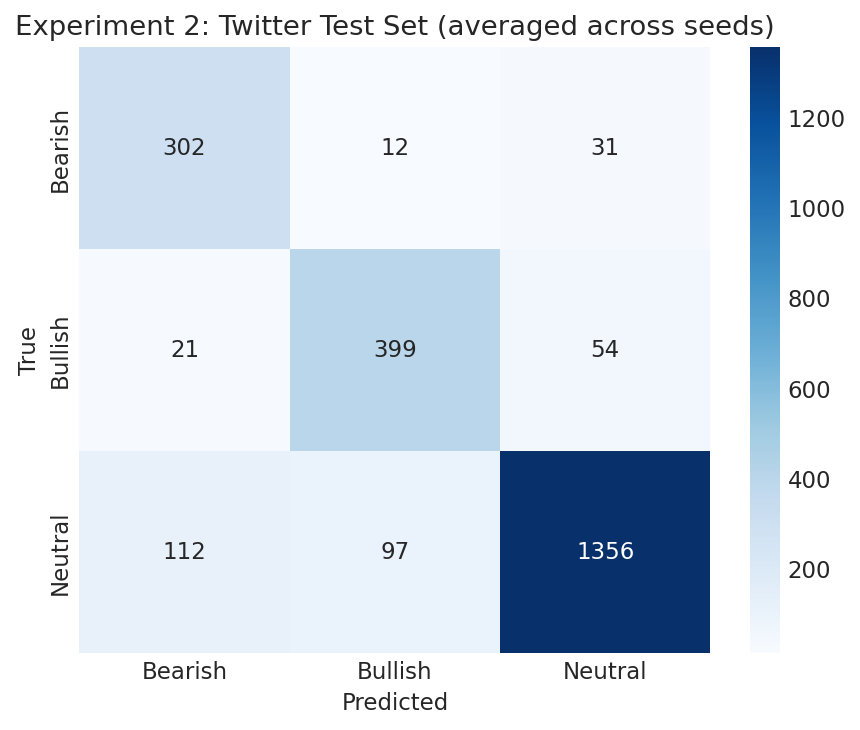

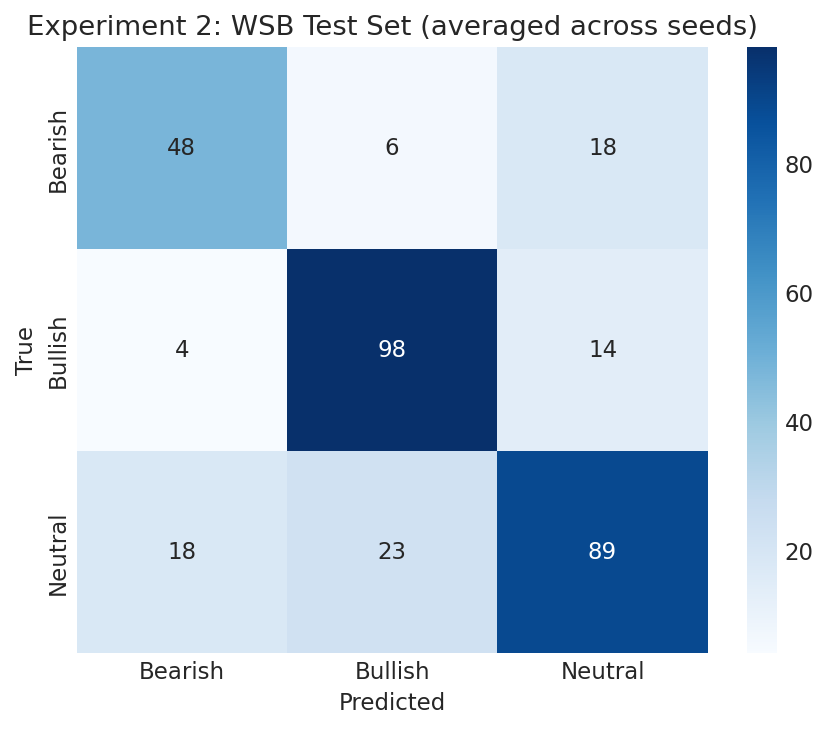

In [46]:
from IPython.display import Image, display

display(Image(os.path.join(FIGURE_DIR, "confusion_matrix_exp2_twitter_avg.png")))
display(Image(os.path.join(FIGURE_DIR, "confusion_matrix_exp2_wsb_avg.png")))

*Twitter test set* performance remains strong and well-distributed across all three classes. Bearish recall is 302/345 (88%), Bullish recall is 399/474 (84%), and Neutral recall is 1356/1565 (87%). Errors are spread across classes rather than concentrated, indicating a well-calibrated model with no dominant failure mode.

*WSB test set* shows a dramatic recovery compared to Experiment 1. The "predict everything as Neutral" collapse is completely resolved, the model now correctly identifies 48/72 Bearish (67%), 98/116 Bullish (84%), and 89/130 Neutral (68%) examples. Bullish is the strongest class, likely because WSB Bullish language ("moon", "gme", "buy") is distinctive enough that even limited training examples create strong decision boundaries. Bearish remains the most challenging class with 18 examples misclassified as Neutral, consistent with the earlier observation that WSB Bearish posts often resemble neutral expressions of confusion or loss rather than analytical bearish sentiment.

### Experiment 3: Generalization to Formal Financial Text (Financial PhraseBank)

In this experiment, both previously trained DistilBERT models are evaluated on the Financial PhraseBank dataset, a corpus of formal financial analyst sentences with human-annotated sentiment labels. No additional training is performed.

This experiment addresses a single question:
Does fine-tuning on informal social media text (Twitter + WSB) hurt generalization to formal financial language?

Financial PhraseBank represents the opposite end of the formality spectrum from WSB, structured analyst sentences with unambiguous sentiment expressions. A model that performs well here alongside WSB demonstrates robust cross-register generalization rather than overfitting to social media linguistic patterns.

Note: Financial PhraseBank is the dataset FinBERT was originally trained on. Results for FinBERT on this dataset are therefore not reported as they would reflect in-domain performance rather than generalization.
The full dataset (4,846 examples) is used as a held-out test set. Labels are remapped from the original positive/negative/neutral schema to our canonical Bullish/Bearish/Neutral mapping.

In [4]:
## Load phrasebank data

bank_ds = load_dataset(PHRASEBANK_PATH)

In [5]:
bank_ds

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 4846
    })
})

In [6]:
## remap labels and rename column to match canonical schema

phrasebank_ds = bank_ds["train"]
phrasebank_ds = phrasebank_ds.map(lambda x: {"label": PHRASEBANK_LABEL_MAP[x["label"]]})
phrasebank_ds = phrasebank_ds.rename_column("sentence", "text")

Map:   0%|          | 0/4846 [00:00<?, ? examples/s]

In [26]:
phrasebank_ds = phrasebank_ds.map(tokenize, batched=True)
phrasebank_ds = phrasebank_ds.rename_column("label", "labels")
phrasebank_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/4846 [00:00<?, ? examples/s]

#### Phrasebank dataset evaluated using the DistilBERT fine-tunned on twitter data

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

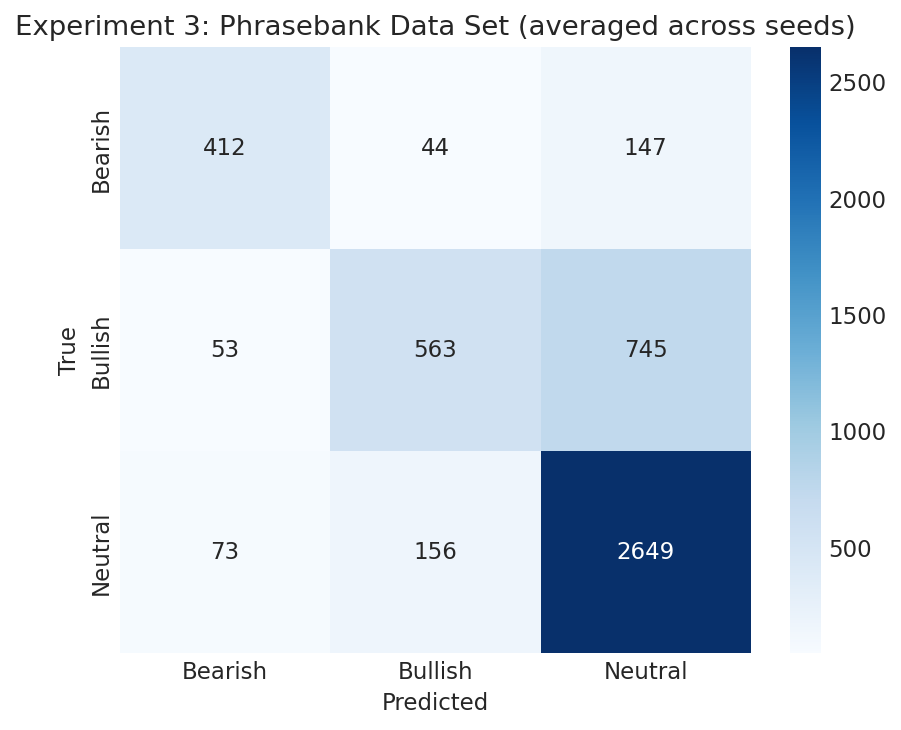

In [34]:
## Phrasebank evaluation loop

results_exp3_twitter_model = []
cms = []
for seed in SEEDS:
    set_seed(seed)
    path = os.path.join(CHECKPOINT_DIR, f"exp1_seed{seed}")
    model = AutoModelForSequenceClassification.from_pretrained(os.path.join(path, "checkpoint-1611"))
    training_args = TrainingArguments(
        output_dir= path,
        per_device_eval_batch_size=BATCH_SIZE,
        fp16=True,
        report_to="none"
    )
    evaluator = WeightedTrainer(
        model=model,
        args=training_args,
        compute_metrics=compute_metrics,
        data_collator=data_collator,
    )
    predictions = evaluator.predict(phrasebank_ds)
    logits = predictions.predictions
    predicted_class = np.argmax(logits, axis =-1)
    true_label = predictions.label_ids
    report = classification_report(true_label, predicted_class, target_names=list(LABEL2ID.keys()),output_dict=True)
    results_exp3_twitter_model.append(
        {"seed": seed,
        "phrasebank_f1_macro": report["macro avg"]["f1-score"],
        "phrasebank_f1_weighted": report["weighted avg"]["f1-score"],
        "phrasebank_accuracy": report["accuracy"]
    })
    cm = confusion_matrix(true_label, predicted_class)
    cms.append(cm)
    
with open(os.path.join(RESULTS_DIR, "exp3_results_twtter_phrasebank.json"), "w") as f:
    json.dump(results_exp3_twitter_model, f, indent=2)

avg_cm = np.array(cms).mean(axis=0).astype(int)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(avg_cm, annot=True, fmt='d', 
            xticklabels=list(LABEL2ID.keys()),
            yticklabels=list(LABEL2ID.keys()),
            cmap='Blues')
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Experiment 3: Phrasebank Data Set (averaged across seeds)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "confusion_matrix_exp3_phrasebank_avg.png"), bbox_inches="tight")

In [35]:
metrics = ["phrasebank_f1_macro", "phrasebank_f1_weighted", "phrasebank_accuracy"]
print("Experiment 3 DistilBERT fine-tuned on Twitter (phrasebank data set)")
print("-" * 60)
for metric in metrics:
    values = [r[metric] for r in results_exp3_twitter_model]
    print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

Experiment 3 DistilBERT fine-tuned on Twitter (phrasebank data set)
------------------------------------------------------------
phrasebank_f1_macro: 0.6918 ± 0.0058
phrasebank_f1_weighted: 0.7290 ± 0.0042
phrasebank_accuracy: 0.7480 ± 0.0055


#### Phrasebank dataset evaluated using the DistilBERT fine-tunned on twitter + WSB data

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

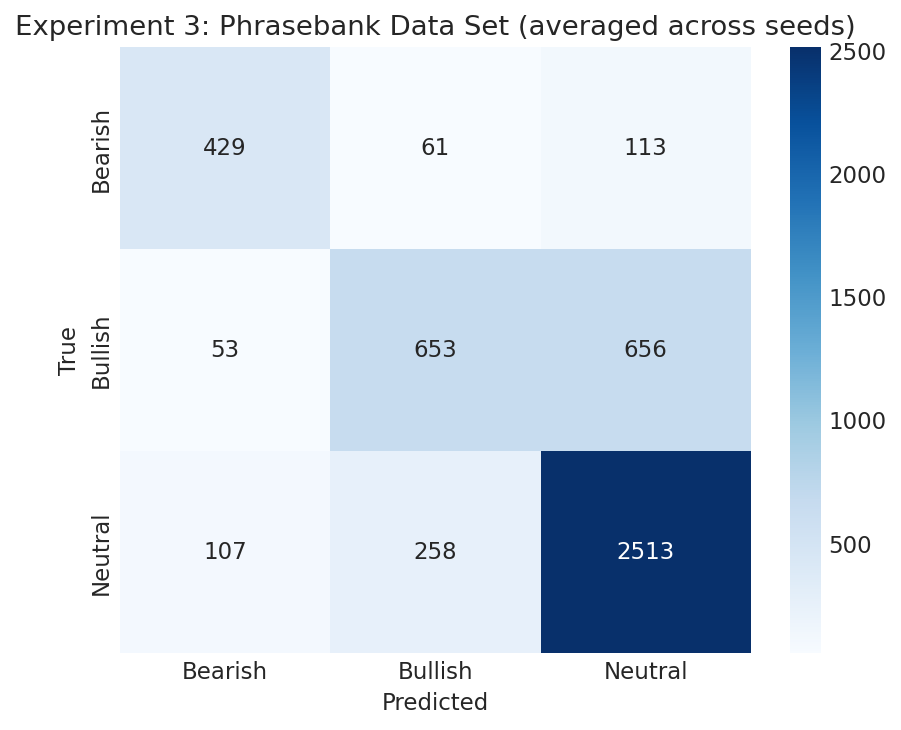

In [41]:
## Phrasebank evaluation loop

results_exp3_twitterWSB_model = []
cms = []
for seed in SEEDS:
    set_seed(seed)
    path = os.path.join(CHECKPOINT_DIR, f"exp2_seed{seed}")
    model = AutoModelForSequenceClassification.from_pretrained(os.path.join(path, "checkpoint-1815"))
    training_args = TrainingArguments(
        output_dir= path,
        per_device_eval_batch_size=BATCH_SIZE,
        fp16=True,
        report_to="none"
    )
    evaluator = WeightedTrainer(
        model=model,
        args=training_args,
        compute_metrics=compute_metrics,
        data_collator=data_collator,
    )
    predictions = evaluator.predict(phrasebank_ds)
    logits = predictions.predictions
    predicted_class = np.argmax(logits, axis =-1)
    true_label = predictions.label_ids
    report = classification_report(true_label, predicted_class, target_names=list(LABEL2ID.keys()),output_dict=True)
    results_exp3_twitterWSB_model.append(
        {"seed": seed,
        "phrasebank_f1_macro": report["macro avg"]["f1-score"],
        "phrasebank_f1_weighted": report["weighted avg"]["f1-score"],
        "phrasebank_accuracy": report["accuracy"]
    })
    cm = confusion_matrix(true_label, predicted_class)
    cms.append(cm)
    
with open(os.path.join(RESULTS_DIR, "exp3_results_twtterWSB_phrasebank.json"), "w") as f:
    json.dump(results_exp3_twitterWSB_model, f, indent=2)

avg_cm = np.array(cms).mean(axis=0).astype(int)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(avg_cm, annot=True, fmt='d', 
            xticklabels=list(LABEL2ID.keys()),
            yticklabels=list(LABEL2ID.keys()),
            cmap='Blues')
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Experiment 3: Phrasebank Data Set (averaged across seeds)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "confusion_matrix_exp3_WSB_phrasebank_avg.png"), bbox_inches="tight")

In [42]:
metrics = ["phrasebank_f1_macro", "phrasebank_f1_weighted", "phrasebank_accuracy"]
print("Experiment 3 DistilBERT fine-tuned on Twitter + WSB (phrasebank data set)")
print("-" * 60)
for metric in metrics:
    values = [r[metric] for r in results_exp3_twitterWSB_model]
    print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

Experiment 3 DistilBERT fine-tuned on Twitter + WSB (phrasebank data set)
------------------------------------------------------------
phrasebank_f1_macro: 0.6979 ± 0.0034
phrasebank_f1_weighted: 0.7314 ± 0.0031
phrasebank_accuracy: 0.7421 ± 0.0054


The Twitter-only model achieves a macro F1 of 0.692 (±0.006), weighted F1 of 0.729 (±0.004), and accuracy of 0.748 (±0.006). Adding WSB data yields marginal gains in macro F1 (0.698 ±0.003) and weighted F1 (0.731 ±0.003), but a slight drop in accuracy (0.742 ±0.005). The differences are within one standard deviation across seeds, indicating no statistically meaningful gap between the two models on this domain.

Both confusion matrices reveal a consistent failure mode: Bullish examples are heavily misclassified as Neutral (745 and 656 respectively), suggesting the models struggle to distinguish positive sentiment from neutral tone in formal analyst languagek, a register quite different from the expressive, emphatic language seen in Twitter and WSB data. Bearish classification is comparatively more reliable, with 412 and 429 correct predictions and lower off-diagonal counts.

Crucially, adding WSB data does not hurt generalisation to formal text. Both models perform at a comparable level on PhraseBank, which answers the core question of this experiment: informal social media fine-tuning does not degrade performance on formal financial language. The modest Bullish recall remains the primary limitation shared across both models.

### Experiment 4: FinBERT Zero-Shot Evaluation on Twitter and WSB Test Sets

In this experiment FinBERT (ProsusAI/finbert) is evaluated in a zero-shot setting, no additional fine-tuning is performed. FinBERT is evaluated directly on the Twitter Financial News test set and the WSB test set using its pre-trained weights.

FinBERT was pre-trained on a large financial corpus and fine-tuned on the Financial PhraseBank dataset, making it a strong domain-specific baseline. This experiment establishes what a finance-specialized model achieves out of the box, before any exposure to social media text.
This experiment addresses two questions:

- Does financial domain pretraining alone transfer to financial social media? FinBERT has never seen Twitter financial news or WSB posts, how does its financial vocabulary help or hurt on these domains?
- Is a domain-pretrained zero-shot model competitive with a general model fine-tuned on the target domain? Comparing FinBERT zero-shot against DistilBERT fine-tuned on Twitter (Experiment 1) reveals whether pretraining or fine-tuning is more valuable for domain transfer.

Label mapping: FinBERT outputs positive/negative/neutral labels which are mapped to our canonical Bullish/Bearish/Neutral schema before evaluation.
Note: No class weights are applied here since no training is performed. Evaluation uses the same macro F1 primary metric and identical test sets as all previous experiments for direct comparability.

In [23]:
## Load FinBERT tokenizer and model

finbert_tokenizer = AutoTokenizer.from_pretrained(FINBERT_NAME)
finbert_model = AutoModelForSequenceClassification.from_pretrained(FINBERT_NAME)

## Sanity check
print("FinBERT internal label mapping:", finbert_model.config.id2label)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT internal label mapping: {0: 'positive', 1: 'negative', 2: 'neutral'}


In [46]:
## Tokenize Twitter and WSB test sets using FinBERT's own tokenizer

def tokenize_finbert(example):
    return finbert_tokenizer(
        example["text"],
        truncation=True,
        max_length=MAX_LEN,
        padding=False
    )

## Twitter test set
twitter_test_finbert = twitter_test.map(tokenize_finbert, batched=True)
twitter_test_finbert = twitter_test_finbert.rename_column("label", "labels")
twitter_test_finbert.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

## WSB test set
wsb_test_hf = Dataset.from_pandas(wsb_test_df.reset_index(drop=True))
wsb_test_finbert = wsb_test_hf.map(tokenize_finbert, batched=True)
wsb_test_finbert = wsb_test_finbert.rename_column("label", "labels")
wsb_test_finbert.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/2388 [00:00<?, ? examples/s]

Map:   0%|          | 0/321 [00:00<?, ? examples/s]

In [48]:
## Shared evaluator
## Using base Trainer since there is no training and class weights are irrelevant

finbert_data_collator = DataCollatorWithPadding(tokenizer=finbert_tokenizer)

training_args_zeroshot = TrainingArguments(
    output_dir=os.path.join(CHECKPOINT_DIR, "exp4_finbert_zeroshot"),
    per_device_eval_batch_size=BATCH_SIZE,
    fp16=True,
    report_to="none"
)

finbert_evaluator = Trainer(
    model=finbert_model,
    args=training_args_zeroshot,
    compute_metrics=compute_metrics,
    data_collator=finbert_data_collator,
)

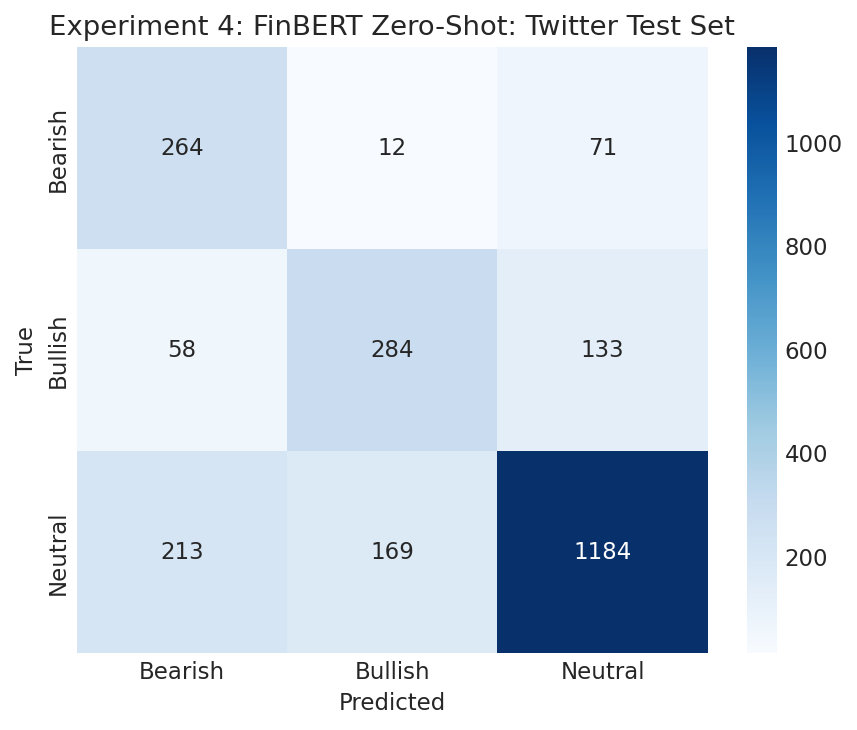

In [49]:
## Zero-Shot on Twitter Test Set

predictions_twitter = finbert_evaluator.predict(twitter_test_finbert)
logits_twitter = predictions_twitter.predictions
predicted_twitter = np.argmax(logits_twitter, axis=-1)

## Remap FinBERT predicted ids to canonical ids
predicted_twitter_remapped = np.array([FINBERT_LABEL_REMAP[p] for p in predicted_twitter])
true_twitter = predictions_twitter.label_ids 

report_twitter = classification_report(
    true_twitter,
    predicted_twitter_remapped,
    target_names=list(LABEL2ID.keys()),
    output_dict=True
)
cm_twitter = confusion_matrix(true_twitter, predicted_twitter_remapped)

with open(os.path.join(RESULTS_DIR, "exp4_results_finbert_zeroshot_twitter.json"), "w") as f:
    json.dump(report_twitter, f, indent=2)

## Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_twitter, annot=True, fmt='d',
            xticklabels=list(LABEL2ID.keys()),
            yticklabels=list(LABEL2ID.keys()),
            cmap='Blues')
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Experiment 4: FinBERT Zero-Shot: Twitter Test Set")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "confusion_matrix_exp4_finbert_zeroshot_twitter.png"), bbox_inches="tight")
plt.show()

In [50]:
print("Experiment 4: FinBERT Zero-Shot on Twitter test set")
print("-" * 60)
print(f"f1_macro:    {report_twitter['macro avg']['f1-score']:.4f}")
print(f"f1_weighted: {report_twitter['weighted avg']['f1-score']:.4f}")
print(f"accuracy:    {report_twitter['accuracy']:.4f}")

Experiment 4: FinBERT Zero-Shot on Twitter test set
------------------------------------------------------------
f1_macro:    0.6682
f1_weighted: 0.7329
accuracy:    0.7253


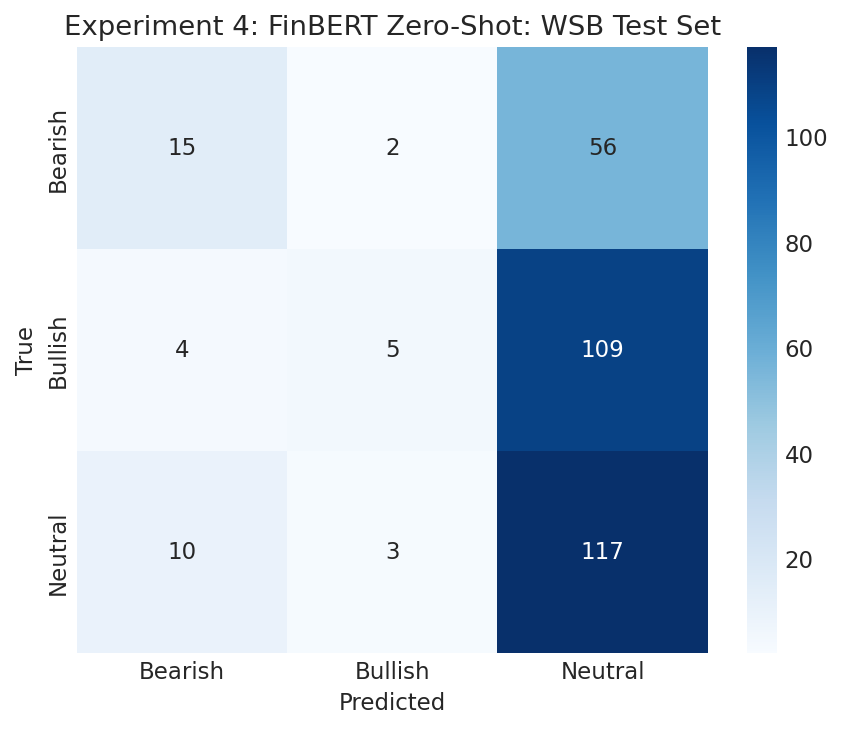

In [51]:
## Zero-Shot on WSB Test Set

predictions_wsb = finbert_evaluator.predict(wsb_test_finbert)
logits_wsb = predictions_wsb.predictions
predicted_wsb = np.argmax(logits_wsb, axis=-1)

## Remap FinBERT predicted ids to canonical ids
predicted_wsb_remapped = np.array([FINBERT_LABEL_REMAP[p] for p in predicted_wsb])
true_wsb = predictions_wsb.label_ids  

report_wsb = classification_report(
    true_wsb,
    predicted_wsb_remapped,
    target_names=list(LABEL2ID.keys()),
    output_dict=True
)
cm_wsb = confusion_matrix(true_wsb, predicted_wsb_remapped)

with open(os.path.join(RESULTS_DIR, "exp4_results_finbert_zeroshot_wsb.json"), "w") as f:
    json.dump(report_wsb, f, indent=2)

## Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_wsb, annot=True, fmt='d',
            xticklabels=list(LABEL2ID.keys()),
            yticklabels=list(LABEL2ID.keys()),
            cmap='Blues')
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Experiment 4: FinBERT Zero-Shot: WSB Test Set")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "confusion_matrix_exp4_finbert_zeroshot_wsb.png"), bbox_inches="tight")
plt.show()

In [52]:
print("Experiment 4: FinBERT Zero-Shot on WSB test set")
print("-" * 60)
print(f"f1_macro:    {report_wsb['macro avg']['f1-score']:.4f}")
print(f"f1_weighted: {report_wsb['weighted avg']['f1-score']:.4f}")
print(f"accuracy:    {report_wsb['accuracy']:.4f}")

Experiment 4: FinBERT Zero-Shot on WSB test set
------------------------------------------------------------
f1_macro:    0.3134
f1_weighted: 0.3256
accuracy:    0.4268


FinBERT zero-shot achieves a macro F1 of 0.668 on the Twitter Financial News test set, a strong result for a model that has never seen this data, reflecting the value of financial domain pretraining. However it falls meaningfully short of DistilBERT fine-tuned on Twitter (0.836), confirming that task-specific fine-tuning outperforms domain pretraining alone when in-domain labeled data is available.

On the WSB test set FinBERT zero-shot achieves a macro F1 of 0.313, marginally better than DistilBERT zero-shot on WSB (0.297) but effectively at the same level. The WSB confusion matrix reveals the same failure mode observed in Experiment 1: near-complete collapse to Neutral predictions, with only 15 Bearish and 5 Bullish posts correctly identified out of 73 and 118 respectively. Financial domain pretraining on formal analyst text provides essentially no advantage over a general model when faced with WSB's informal meme-driven register.

#### Comparison with DistilBERT

Two findings emerge from this comparison. First, fine-tuning a general model on domain-specific data (DistilBERT + Twitter) substantially outperforms a domain-pretrained model in zero-shot setting (FinBERT) - 0.836 vs 0.668 on Twitter. Second, both models fail comparably on WSB without WSB training data, suggesting the domain gap between formal financial text and WSB's informal register is too large for pretraining alone to bridge. The critical factor for WSB performance is exposure to WSB training examples, not the quality of the pretrained model.

### Experiment 5: FinBERT Fine-tuned on Twitter + WSB

In this experiment we fine-tune FinBERT on the combined Twitter + WSB training set, the same training data used in Experiment 2, and evaluate on both the Twitter and WSB test sets. This is the final training experiment and directly mirrors Experiment 2, with FinBERT replacing DistilBERT as the base model.

This experiment addresses the core research question of the project:

Does financial domain pretraining provide an advantage when both models are fine-tuned on the same social media data?
By holding the training data constant and varying only the base model, general purpose DistilBERT vs finance-specialized FinBERT, we can isolate the contribution of domain pretraining to final performance. If FinBERT outperforms DistilBERT after fine-tuning on the same data, domain pretraining adds value beyond what task-specific fine-tuning provides. If performance is comparable, fine-tuning on sufficient labeled data renders pretraining domain less relevant.

The model is trained three times with different random seeds (26, 42, 74). Class weights computed on the combined Twitter + WSB training set are reused from Experiment 2. Results are reported as mean ± standard deviation across seeds and compared directly against Experiment 2 (DistilBERT) results.

In [24]:
def tokenize_finbert(example):
    return finbert_tokenizer(
        example["text"],
        truncation=True,
        max_length=MAX_LEN,
        padding=False
    )

In [25]:
## Combined Twitter + WSB training and validation sets

label_feature = ClassLabel(names=["Bearish", "Bullish", "Neutral"])

wsb_train_hf = Dataset.from_pandas(wsb_train_df.reset_index(drop=True))

wsb_train_hf = wsb_train_hf.cast_column("label", label_feature)

combined_train = concatenate_datasets([
    twitter_train.map(tokenize_finbert, batched=True),
    wsb_train_hf.map(tokenize_finbert, batched=True)
])

combined_train = combined_train.rename_column("label", "labels")
combined_train.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])


Casting the dataset:   0%|          | 0/1088 [00:00<?, ? examples/s]

Map:   0%|          | 0/1088 [00:00<?, ? examples/s]

In [27]:
## Twitter val set
twitter_val_finbert = twitter_val_hf.map(tokenize_finbert, batched=True)
twitter_val_finbert = twitter_val_finbert.rename_column("label", "labels")
twitter_val_finbert.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

## Twitter test set
twitter_test_finbert = twitter_test.map(tokenize_finbert, batched=True)
twitter_test_finbert = twitter_test_finbert.rename_column("label", "labels")
twitter_test_finbert.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

## WSB test set
wsb_test_hf = Dataset.from_pandas(wsb_test_df.reset_index(drop=True))
wsb_test_finbert = wsb_test_hf.map(tokenize_finbert, batched=True)
wsb_test_finbert = wsb_test_finbert.rename_column("label", "labels")
wsb_test_finbert.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/955 [00:00<?, ? examples/s]

Map:   0%|          | 0/321 [00:00<?, ? examples/s]

In [28]:
## recompute class weights on combined training set

combined_labels = np.concatenate([twitter_train_df["label"].values, wsb_train_df["label"].values])

class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(combined_labels), y=combined_labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights (combined Twitter + WSB training set):")
for class_id, weight in zip(np.unique(combined_labels), class_weights):
    print(f"  {ID2LABEL[class_id]}: {weight:.3f}")

Class weights (combined Twitter + WSB training set):
  Bearish: 2.085
  Bullish: 1.516
  Neutral: 0.537


In [29]:
## Define metrics to evaluate model

def compute_metrics(eval_pred) -> dict:
    """Compute weighted F1 and accuracy for evaluation."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "f1_macro": f1_score(labels, predictions, average="macro"),
        "f1_weighted": f1_score(labels, predictions, average="weighted"),
        "accuracy": accuracy_score(labels, predictions)
    }

#### Trainer

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Accuracy
1,0.570934,0.548614,0.765315,0.818536,0.812565
2,0.401068,0.529497,0.779304,0.827066,0.820942
3,0.225113,0.694001,0.793575,0.843076,0.839791


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Accuracy
1,0.522354,0.546194,0.771885,0.825824,0.820942
2,0.378336,0.566194,0.789254,0.836889,0.833508
3,0.200114,0.691400,0.803540,0.848702,0.846073


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

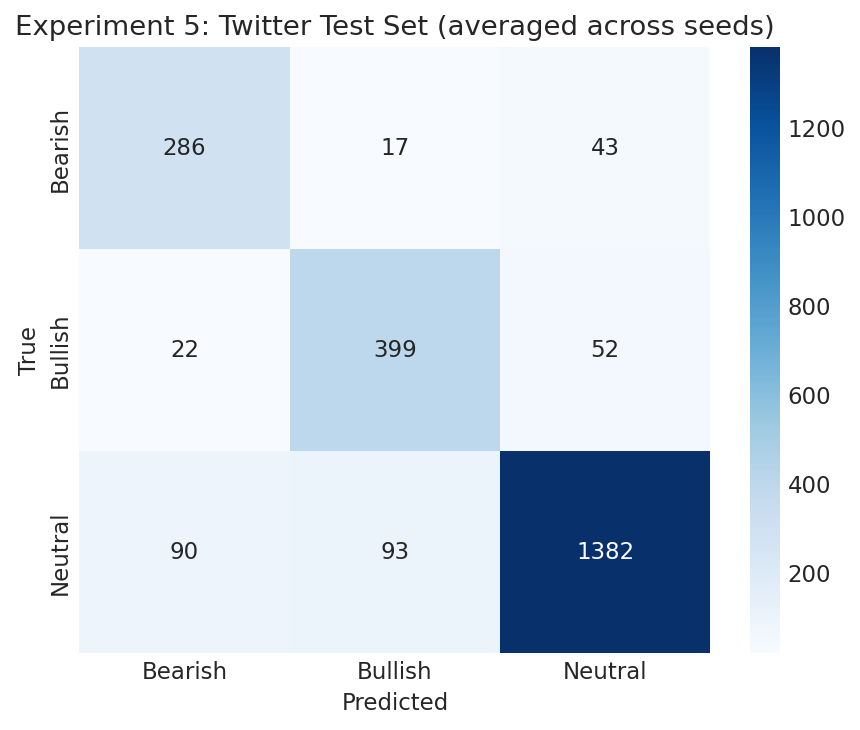

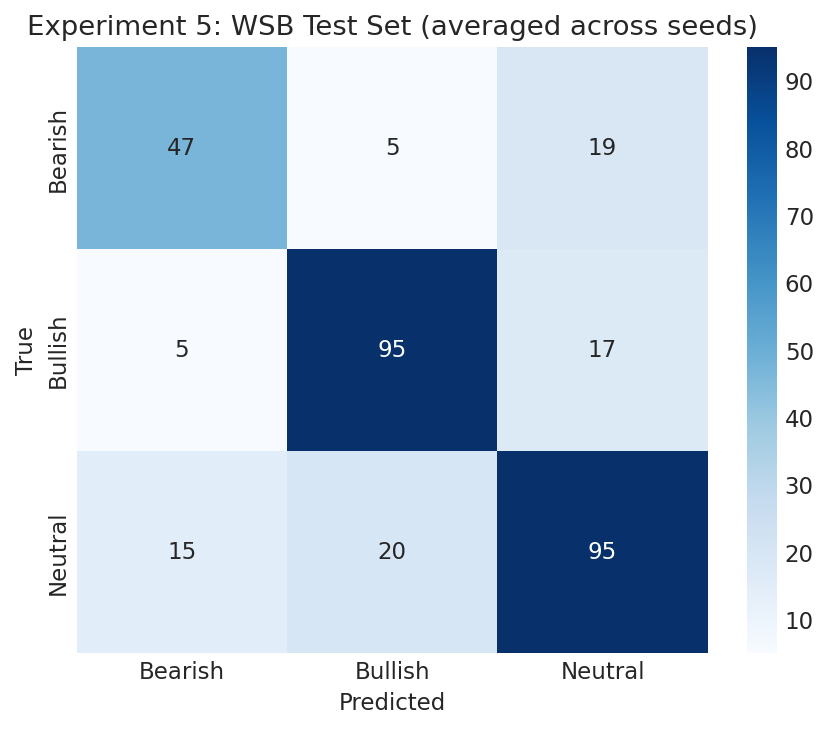

In [31]:
## Setting up model and training arguments

results_exp5_twitter = []
results_exp5_wsb = []
cms_twitter = []
cms_wsb = []
finbert_data_collator = DataCollatorWithPadding(tokenizer=finbert_tokenizer)
for seed in SEEDS:

    set_seed(seed)
    
    model = AutoModelForSequenceClassification.from_pretrained(FINBERT_NAME, num_labels=3,id2label=ID2LABEL,label2id=LABEL2ID,ignore_mismatched_sizes=True)
    
    os.makedirs(os.path.join(CHECKPOINT_DIR, f"exp5_seed{seed}"), exist_ok=True)
    
    training_args = TrainingArguments(
        output_dir= os.path.join(CHECKPOINT_DIR, f"exp5_seed{seed}"),
        num_train_epochs= EPOCHS,
        per_device_train_batch_size= BATCH_SIZE,
        per_device_eval_batch_size= BATCH_SIZE,
        learning_rate= LEARNING_RATE,
        weight_decay= WEIGHT_DECAY,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end= True,
        metric_for_best_model= EVAL_METRIC,
        fp16=True,
        logging_dir= LOGGING_DIR,
        logging_steps=50,
        warmup_ratio=WARMUP_RATIO,
        save_total_limit=1,
        seed=seed,
        report_to="none",
        run_name=f"distilbert_twitterAndWSB_seed{seed}",
        greater_is_better=True,
    )
    
    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=combined_train,
        eval_dataset=twitter_val_finbert,
        compute_metrics=compute_metrics,
        data_collator=finbert_data_collator
    )
    
    trainer.train()

    predictions = trainer.predict(twitter_test_finbert)
    
    logits = predictions.predictions
    predicted_class = np.argmax(logits, axis =-1)
    true_label = predictions.label_ids
    cm = confusion_matrix(true_label, predicted_class)
    cms_twitter.append(cm)
    report = classification_report(true_label, predicted_class, target_names=list(LABEL2ID.keys()),output_dict=True)
    results_exp5_twitter.append(
        {"seed": seed,
        "twitter_f1_macro": report["macro avg"]["f1-score"],
        "twitter_f1_weighted": report["weighted avg"]["f1-score"],
        "twitter_accuracy": report["accuracy"]
    })

    predictions = trainer.predict(wsb_test_finbert)
    
    logits = predictions.predictions
    predicted_class = np.argmax(logits, axis =-1)
    true_label = predictions.label_ids
    cm = confusion_matrix(true_label, predicted_class)
    cms_wsb.append(cm)
    report = classification_report(true_label, predicted_class, target_names=list(LABEL2ID.keys()),output_dict=True)
    results_exp5_wsb.append(
        {"seed": seed,
        "WSB_f1_macro": report["macro avg"]["f1-score"],
        "WSB_f1_weighted": report["weighted avg"]["f1-score"],
        "WSB_accuracy": report["accuracy"]
    })
    
with open(os.path.join(RESULTS_DIR, "exp5_results_twitter.json"), "w") as f:
    json.dump(results_exp5_twitter, f, indent=2)
with open(os.path.join(RESULTS_DIR, "exp5_results_wsb.json"), "w") as f:
    json.dump(results_exp5_wsb, f, indent=2)
    
avg_cm_twitter = np.array(cms_twitter).mean(axis=0).astype(int)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(avg_cm_twitter, annot=True, fmt='d', 
            xticklabels=list(LABEL2ID.keys()),
            yticklabels=list(LABEL2ID.keys()),
            cmap='Blues')
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Experiment 5: Twitter Test Set (averaged across seeds)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "confusion_matrix_exp5_twitter_avg.png"), bbox_inches="tight")

avg_cm_wsb = np.array(cms_wsb).mean(axis=0).astype(int)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(avg_cm_wsb, annot=True, fmt='d', 
            xticklabels=list(LABEL2ID.keys()),
            yticklabels=list(LABEL2ID.keys()),
            cmap='Blues')
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Experiment 5: WSB Test Set (averaged across seeds)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "confusion_matrix_exp5_wsb_avg.png"), bbox_inches="tight")

In [32]:
metrics = ["twitter_f1_macro", "twitter_f1_weighted", "twitter_accuracy"]
print("Experiment 5 FinBERT fine-tuned on Twitter + WSB (Twitter test set)")
print("-" * 60)
for metric in metrics:
    values = [r[metric] for r in results_exp5_twitter]
    print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

Experiment 5 FinBERT fine-tuned on Twitter + WSB (Twitter test set)
------------------------------------------------------------
twitter_f1_macro: 0.8292 ± 0.0013
twitter_f1_weighted: 0.8685 ± 0.0012
twitter_accuracy: 0.8663 ± 0.0012


In [33]:
metrics = ["WSB_f1_macro", "WSB_f1_weighted", "WSB_accuracy"]
print("Experiment 5 FinBERT fine-tuned on Twitter + WSB (WSB test set)")
print("-" * 60)
for metric in metrics:
    values = [r[metric] for r in results_exp5_wsb]
    print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

Experiment 5 FinBERT fine-tuned on Twitter + WSB (WSB test set)
------------------------------------------------------------
WSB_f1_macro: 0.7338 ± 0.0135
WSB_f1_weighted: 0.7415 ± 0.0122
WSB_accuracy: 0.7425 ± 0.0115


FinBERT fine-tuned on the combined Twitter + WSB dataset achieves a macro F1 of 0.829 on Twitter and 0.734 on WSB. Notably, FinBERT exhibits remarkably low variance across seeds (std=0.0013 on Twitter, std=0.0135 on WSB) compared to DistilBERT (std=0.0046 on Twitter, std=0.0192 on WSB), suggesting that financial domain pretraining produces a more stable optimization landscape when fine-tuning on social media financial text.
The Twitter confusion matrix shows strong performance across all three classes: Bearish recall is 286/346 (83%), Bullish 399/473 (84%) and Neutral 1382/1565 (88%), with errors well distributed rather than concentrated, indicating no dominant failure mode.

The WSB confusion matrix reveals a well-calibrated model with no class collapse. Bearish recall is 47/71 (66%), Bullish 95/117 (81%) and Neutral 95/130 (73%). The improvement over Experiment 2 DistilBERT is modest but consistent across all three classes.

#### Comparison: FinBERT vs DistilBERT Fine-tuned on Twitter + WSB

The comparison reveals a striking finding: when fine-tuned on identical training data, FinBERT and DistilBERT achieve essentially equivalent performance. The macro F1 difference is negligible on Twitter (+0.0005) and modest on WSB (+0.009), both well within the margin of practical significance. Financial domain pretraining provides no meaningful performance advantage over a general model when sufficient labeled social media data is available for fine-tuning.

However, FinBERT's substantially lower variance across seeds is a practically important finding, it suggests financial domain pretraining produces more reliable and reproducible fine-tuning, which matters in production settings where training stability is valued.

## Results Summary & Discussion

###  Full Results Table

| Experiment | Model | Train Data | Eval Set | Macro F1 | Weighted F1 | Accuracy |
|------------|-------|------------|----------|----------|-------------|----------|
| 1 | DistilBERT | Twitter | Twitter Test | 0.8361 ± 0.0030 | 0.8729 ± 0.0027 | 0.8710 ± 0.0029 |
| 1 | DistilBERT | Twitter | WSB Test | 0.2972 ± 0.0092 | 0.3278 ± 0.0074 | 0.4351 ± 0.0029 |
| 2 | DistilBERT | Twitter + WSB | Twitter Test | 0.8287 ± 0.0046 | 0.8652 ± 0.0033 | 0.8621 ± 0.0037 |
| 2 | DistilBERT | Twitter + WSB | WSB Test | 0.7249 ± 0.0192 | 0.7322 ± 0.0191 | 0.7342 ± 0.0184 |
| 3 | DistilBERT | Twitter | PhraseBank | 0.6918 ± 0.0058 | 0.7290 ± 0.0042 | 0.7480 ± 0.0055 |
| 3 | DistilBERT | Twitter + WSB | PhraseBank | 0.6979 ± 0.0034 | 0.7314 ± 0.0031 | 0.7421 ± 0.0054 |
| 4 | FinBERT | None (zero-shot) | Twitter Test | 0.6682 | 0.7329 | 0.7253 |
| 4 | FinBERT | None (zero-shot) | WSB Test | 0.3134 | 0.3256 | 0.4268 |
| 5 | FinBERT | Twitter + WSB | Twitter Test | 0.8292 ± 0.0013 | 0.8685 ± 0.0012 | 0.8663 ± 0.0012 |
| 5 | FinBERT | Twitter + WSB | WSB Test | 0.7338 ± 0.0135 | 0.7415 ± 0.0122 | 0.7425 ± 0.0115 |

### Key Findings
- Finding 1: The domain gap between formal financial Twitter and informal WSB is severe and consistent.
DistilBERT trained exclusively on Twitter collapses almost entirely to predicting Neutral on WSB data, achieving a macro F1 of 0.297, barely above random chance (0.333). The same failure mode is observed for FinBERT zero-shot on WSB (0.313). Neither financial domain pretraining nor Twitter fine-tuning provides meaningful transfer to WSB's meme-driven, emotionally charged register without explicit WSB training examples.
- Finding 2: A small amount of in-domain data dramatically bridges the domain gap.
Adding just 1,088 WSB training examples to the Twitter training set improves DistilBERT's WSB macro F1 from 0.297 to 0.725, a 144% relative improvement. Critically, this adaptation comes at negligible cost to Twitter performance (0.836 → 0.829), demonstrating that the model successfully adapts to WSB's informal register without catastrophic forgetting of Twitter financial vocabulary.
- Finding 3: Financial domain pretraining does not outperform general pretraining when fine-tuning data is available.
When fine-tuned on identical Twitter + WSB training data, FinBERT and DistilBERT achieve essentially equivalent performance, 0.829 vs 0.829 on Twitter and 0.734 vs 0.725 on WSB. The macro F1 differences fall within normal training variance. This finding suggests that labeled fine-tuning data is the dominant factor in determining performance, and that the benefit of financial domain pretraining is largely subsumed by task-specific fine-tuning on sufficient social media data.
- Finding 4: Financial domain pretraining improves training stability.
Despite similar final performance, FinBERT exhibits substantially lower variance across seeds compared to DistilBERT, std=0.0013 vs 0.0046 on Twitter and std=0.0135 vs 0.0192 on WSB. This suggests financial domain pretraining produces a more stable optimization landscape, which has practical implications for production deployments where reproducibility is valued.
- Finding 5: Zero-shot financial domain knowledge transfers better to formal financial text than to social media.
FinBERT zero-shot achieves a respectable 0.668 macro F1 on Twitter Financial News, reflecting meaningful transfer from its Financial PhraseBank pretraining to curated financial news tweets. However this advantage disappears entirely on WSB (0.313), confirming that the linguistic register gap between formal financial text and retail investor social media is too large for pretraining alone to bridge.
- Finding 6: WSB fine-tuning does not hurt generalization to formal financial text.
DistilBERT fine-tuned on Twitter + WSB achieves a PhraseBank macro F1 of 0.698, compared to 0.692 for the Twitter-only model, a negligible difference of 0.006. Adding informal WSB training data neither helps nor hurts performance on formal analyst sentences, suggesting the two domains occupy sufficiently distinct linguistic spaces that learning one does not interfere with the other. This is a practically important finding: domain adaptation to informal social media text can be performed without sacrificing performance on formal financial NLP tasks.

### Limitations

Several limitations should be noted when interpreting these results. First, the WSB dataset contains only 1,602 examples concentrated around the January 2021 GameStop short squeeze event, results may not generalize to WSB posts from other time periods or market conditions. Second, label noise in the WSB dataset is non-trivial, as evidenced by qualitatively ambiguous examples in the EDA section where bearish sentiment manifests as expressions of personal loss rather than analytical judgment. Third, all experiments use a fixed set of hyperparameters optimized for DistilBERT, a dedicated hyperparameter search for FinBERT may yield improved results. Finally, macro F1 as a primary metric treats all classes equally, which may not reflect real-world deployment priorities where bearish sentiment detection carries higher practical value.